# Data-Driven Analysis of Potato Aroma: Genotype–VOC–Sensory Integration (Biorep1)

This notebook documents the executable analysis workflow underlying the
graduation thesis *“Data-Driven Analysis of Potato Flavour and Aroma Using
TD–GC–MS and Machine Learning”*.

The focus of this notebook is to:
- PCA and multivariate analysis on genetic-aroma dataset
- Prioritise genetic markers using GWAS as a feature selection strategy
- Evaluate genetic predictability of aroma compounds
- linking genetic to aroma compounds
- Integrate genetically predicted VOCs with reconstructed sensory space to see the link of genetic-aroma-sensory profile

_ This notebook should be run by  genemarker_module.py

In [1]:
import pandas as pd
import re
import os
from sklearn.cross_decomposition import PLSRegression
import numpy as np
from pathlib import Path
from statsmodels.formula.api import ols
import statsmodels.api as sm
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression
import yaml
!pip install network
import networkx as nx
import importlib   
import genemarker_module
importlib.reload(genemarker_module)


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


<module 'genemarker_module' from 'c:\\Users\\fatemehm\\OneDrive - Royal HZPC Group\\documents\\GitHub\\internship\\functions\\genemarker_module.py'>

# Data Loading (genetic dataset, aroma dataset and sensory dataset)

In [2]:
with open("config.yaml", "r", encoding="utf-8") as f:
    config = yaml.safe_load(f)

# Paths for Biorep1
genetic_path = config["biorep1"]["data"]["genetic_data"]
aroma_path   = config["biorep1"]["data_paths"]["aroma_matrix_output"]
pc_projection_path = config["biorep1"]["data_paths"]["sensory_pca"]["projection_path"]

# Load data
genetic_data = pd.read_csv(genetic_path)
aroma_df     = pd.read_csv(aroma_path)
sensory_pcs  = pd.read_csv(pc_projection_path)

# Remove duplicate columns
sensory_pcs = sensory_pcs.loc[:, ~sensory_pcs.columns.duplicated()]

# Remove useless 'Unnamed:' columns
sensory_pcs = sensory_pcs.loc[:, ~sensory_pcs.columns.str.contains("Unnamed")]

# Normalize Variety column
if "VARIETY" in sensory_pcs.columns:
    sensory_pcs = sensory_pcs.rename(columns={"VARIETY": "Variety"})
elif "Variety_original" in sensory_pcs.columns:
    sensory_pcs = sensory_pcs.rename(columns={"Variety_original": "Variety"})

print("Final sensory PCA columns:", sensory_pcs.columns.tolist())
print("Variety exists:", "Variety" in sensory_pcs.columns)


Final sensory PCA columns: ['Variety', 'PC1', 'PC2', 'PC3', 'is_panel']
Variety exists: True


# Alignment and merging of genotype and phenotype tables


In [ ]:

from genemarker_module import merge_genetic_aroma_sensory
import os
# Clean Variety labels consistently
sensory_pcs["Variety"] = sensory_pcs["Variety"].astype(str).str.strip()
aroma_df["Variety"]  = aroma_df["Variety"].astype(str).str.strip()

# If sensory has duplicates per Variety, average numeric columns
sensory_pcs = (sensory_pcs
               .groupby("Variety", as_index=False)
               .mean(numeric_only=True))


REP = "biorep1"
#  Run merge function 
merged_snp_aroma, merged_snp_sensory, merged_all = merge_genetic_aroma_sensory(
    genetic_data, aroma_df, sensory_pcs
)

cols_to_drop = [c for c in merged_snp_aroma.columns if c.startswith("Unnamed")]
merged_snp_aroma = merged_snp_aroma.drop(columns=cols_to_drop, errors="ignore")

if "sensory_pcs" not in globals() or sensory_pcs is None:
    sensory_pcs = pd.DataFrame({"Variety": aroma_df["Variety"].astype(str).values})

merged_snp_aroma, merged_snp_sensory, merged_all = merge_genetic_aroma_sensory(
    genetic_data=genetic_data,
    aroma_df=aroma_df,
    sensory_pcs=sensory_pcs
)

merged_snp_aroma = merged_snp_aroma.apply(pd.to_numeric, errors="coerce").fillna(0)
merged_snp_aroman = merged_snp_aroma.loc[:, merged_snp_aroma.std(ddof=0) > 0]

print("merged_snp_aroma_clean shape:", merged_snp_aroma.shape)

# Save path from config
out_path = config[REP]["data"]["merged_snp_aroma_output"]

# Ensure output directory exists
os.makedirs(os.path.dirname(out_path), exist_ok=True)

merged_snp_aroma.to_csv(out_path, index=False)
print("Saved:", out_path)


 Genetic table after reshape: (94, 262434)

# Aroma data cleanup summary:
  Total columns before: 67
  Dropped (all NaN): 0
  Final usable aroma columns: 67
  Sample aroma cols: ['Unnamed: 0', '(E)-2-Decenal', '(E, E)-2,4-Decadienal', '1-Heptanol', '1-Nonanol', '1-Octen-3-ol', '1-Penten-3-one', '1-Phenylethanol']

# Sensory PCs: 3
Sample sensory cols: ['PC1', 'PC2', 'PC3']

# Merge results:
  Genetic + Aroma: (94, 262501)
  Genetic + Sensory: (94, 262437)
  Genetic + Aroma + Sensory: (94, 262504)
 Genetic table after reshape: (94, 262434)

# Aroma data cleanup summary:
  Total columns before: 67
  Dropped (all NaN): 0
  Final usable aroma columns: 67
  Sample aroma cols: ['Unnamed: 0', '(E)-2-Decenal', '(E, E)-2,4-Decadienal', '1-Heptanol', '1-Nonanol', '1-Octen-3-ol', '1-Penten-3-one', '1-Phenylethanol']

# Sensory PCs: 3
Sample sensory cols: ['PC1', 'PC2', 'PC3']

# Merge results:
  Genetic + Aroma: (94, 262501)
  Genetic + Sensory: (94, 262437)
  Genetic + Aroma + Sensory: (94, 2625

# Exploratory analysis:

# 1.PCA of Genetic–Aroma Dataset

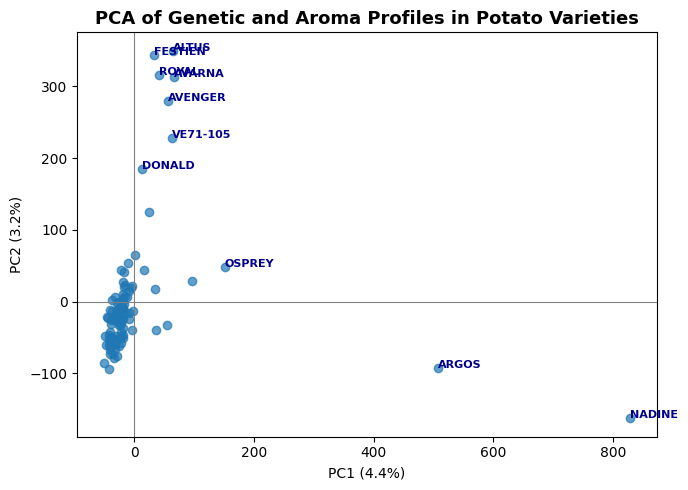

 PCA completed with 3 components.
Explained variance (first 2 PCs): [0.04357351 0.03249596]
Top 10% outliers: ['ALTUS', 'ARGOS', 'AVARNA', 'AVENGER', 'DONALD', 'FESTIEN', 'NADINE', 'OSPREY', 'ROYAL', 'VE71-105']


In [ ]:

from genemarker_module import perform_pca_with_outliers

pca_df, outliers, pca_model = perform_pca_with_outliers(
    merged_snp_aroma,
    n_components=3,
    outlier_percent=10,
    title="PCA of Genetic and Aroma Profiles in Potato Varieties"
)


Most varieties cluster tightly near the origin, indicating broadly similar combined genetic–aroma profiles in the first two PCs (PC1 4.4%, PC2 3.3% of variance). A small set of varieties (e.g., NADINE, ARGOS, DONALD, OSPREY) sit far from the main cloud, acting as clear outliers that drive much of the separation in this PCA space.

# Feature selection

# Genome-Wide Association Study (GWAS) 

In [ ]:
from genemarker_module import perform_gwas_lmm_for_traits_fast

cols = merged_snp_aroma.columns.astype(str).str.strip()

aroma_traits = [c for c in cols if c != "Variety" and not c.startswith("GEN__")]

gwas_gene_aroma_output = config["biorep1"]["data"]["gwas_output_gene_aroma"]

res_all = perform_gwas_lmm_for_traits_fast(
    merged_df=merged_all,          
    traits=aroma_traits,
    output_path=gwas_gene_aroma_output,
    trait_missing="mean",        
    kinship_snps=20000,            
    precompute_UX=True,           
    block_size=50000,
    delta_grid=40,
    top_n_snps=500,
    ld_threshold=0.95,
    verbose=True
)


[    0.52s] Stage 1/9: Detect SNP columns
[    0.68s] Stage 2/9: Extract SNP matrix (single shot)
[    1.77s]   Raw SNP matrix: n=94, m=262434
[    1.77s] Stage 3/9: SNP QC (missingness / impute / monomorphic / MAF)
[    7.10s]   After QC: n=94, m=121023 SNPs
[    7.10s] Stage 4/9: Detect trait columns
[    7.58s]   Traits to test: 67
[    7.59s] Stage 5/9: Build PCs + covariates
[    7.62s]   Using 20000 SNPs to build K/PCs (subset)
[    7.81s]   Fixed effects cols=6 (1 intercept + 5 PCs + 0 extras)
[    7.81s] Stage 6/9: Kinship (K) + eigendecomposition
[    7.91s]   Precomputing UX = U.T @ X (this may take a bit, but speeds trait loop)
[    8.21s] Stage 7/9: GWAS trait loop
[   19.33s]   [1/67] Trait=Unnamed: 0 done | n=94 | top=160 | 11.12s
[   35.88s]   [2/67] Trait=(E)-2-Decenal done | n=94 | top=258 | 16.55s
[   56.29s]   [3/67] Trait=(E, E)-2,4-Decadienal done | n=94 | top=269 | 20.41s
[   68.14s]   [4/67] Trait=1-Heptanol done | n=94 | top=189 | 11.85s
[   83.88s]   [5/67] Tra

KeyboardInterrupt: 

fast LMM-based GWAS for 67 aroma traits using 94 varieties, starting from 262,434 SNPs and retaining 121,023 SNPs after QC. Population structure and relatedness were controlled using a kinship matrix plus 5 genetic PCs

# Multi-trait GWAS using ACAT aggregation


In [ ]:

from genemarker_module import run_gwas_multitrait_with_population_structure

mt_top, mt_all = run_gwas_multitrait_with_population_structure(
    merged_df=merged_all,
    traits=aroma_traits,         
    snp_prefix="GEN__",
    ploidy=4,
    n_pcs=5,                     # population structure
    top_n_snps=500,
    ld_threshold=0.9,
    output_dir="/Results",
    output_basename="gwas_aroma_multitrait_acat",
    precompute_UX=True,
    verbose=True
)

mt_top


[multi-trait GWAS] merged_df shape: (94, 262504)
[multi-trait GWAS] #SNPs: 262434 | #traits: 67
[multi-trait GWAS] n_pcs=5 | top_n_snps=500 | ld_threshold=0.9
[multi-trait GWAS] per-trait out: /Results\gwas_aroma_multitrait_acat_per_trait.csv
[multi-trait GWAS] multi-trait out: /Results\gwas_aroma_multitrait_acat.csv
[    0.89s] Stage 1/9: Detect SNP columns
[    1.20s] Stage 2/9: Extract SNP matrix (single shot)
[    4.04s]   Raw SNP matrix: n=94, m=262434
[    4.04s] Stage 3/9: SNP QC (missingness / impute / monomorphic / MAF)
[    9.26s]   After QC: n=94, m=121023 SNPs
[    9.26s] Stage 4/9: Detect trait columns
[    9.47s]   Traits to test: 67
[    9.48s] Stage 5/9: Build PCs + covariates
[    9.55s]   Using 20000 SNPs to build K/PCs (subset)
[    9.74s]   Fixed effects cols=6 (1 intercept + 5 PCs + 0 extras)
[    9.74s] Stage 6/9: Kinship (K) + eigendecomposition
[    9.78s]   Precomputing UX = U.T @ X (this may take a bit, but speeds trait loop)
[    9.98s] Stage 7/9: GWAS trait 

,SNP,ACAT_p,n_traits_used,min_p,ACAT_fdr
0,GEN__501710,8.193446e-14,3,2.731300e-14,3.048781e-10
1,GEN__535993,3.095540e-11,3,1.031930e-11,5.759253e-08
2,GEN__1532,5.604012e-11,21,2.668550e-12,6.950843e-08
3,GEN__34740,4.405065e-10,1,4.405065e-10,4.097812e-07
4,GEN__348036,2.397418e-09,1,2.397419e-09,1.784159e-06
...,...,...,...,...,...
495,GEN__292433,2.812350e-04,1,2.812350e-04,2.109829e-03
496,GEN__437479,2.824445e-04,1,2.824445e-04,2.110881e-03
497,GEN__257966,2.825097e-04,1,2.825097e-04,2.110881e-03
498,GEN__439325,2.836109e-04,15,5.262437e-05,2.111794e-03


A multi-trait GWAS across 67 aroma traits in 94 varieties, applying SNP QC (262,434 → 121,023 SNPs) and controlling population structure with 5 genetic PCs. Per-trait GWAS results are then aggregated using an ACAT-based multi-trait statistic, and the pipeline returns mt_all (3,721 SNPs tested) plus mt_top (top 500, LD-pruned at 0.9)

# Visulization of GWAS plot inclusing manhattan plot, volcano plot and QQ plot

c:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\functions\genemarker_module.py:777: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
c:\Users\fatemehm\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


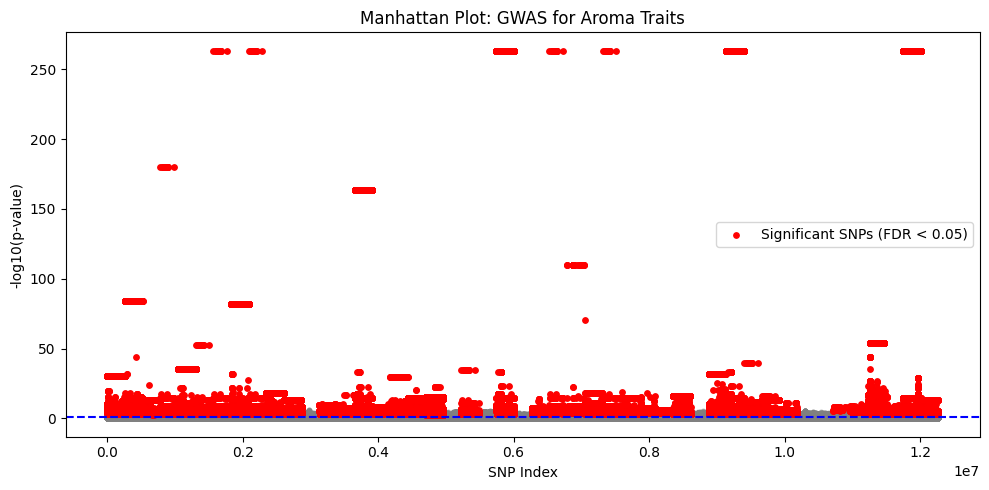

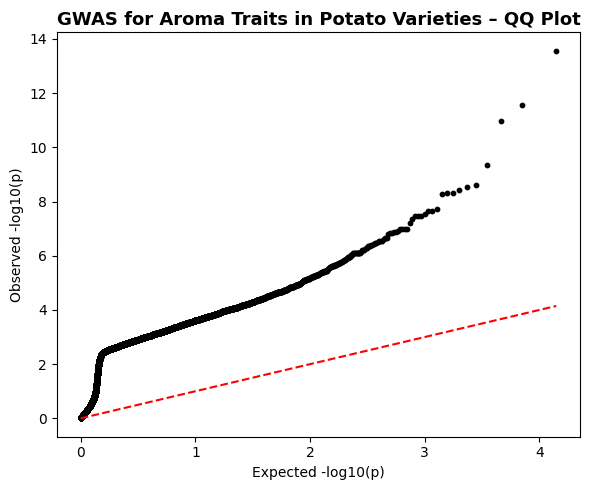

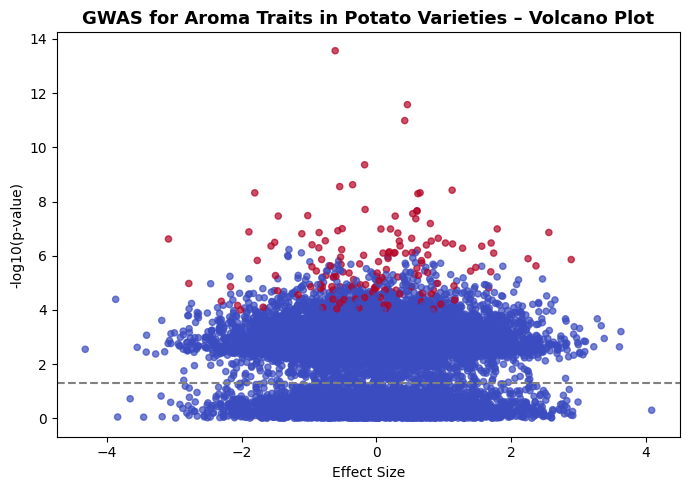

In [ ]:

from genemarker_module import plot_gwas_full_report


#  Read file into DataFrame
gwas_df = pd.read_csv(gwas_gene_aroma_output)

# Call plotting function with the DataFrame
plot_gwas_full_report(
    gwas_df,
    title_prefix="GWAS for Aroma Traits in Potato Varieties"
)



The Manhattan plot shows multiple strong association peaks across the genome, with many SNPs passing the FDR < 0.05 threshold, suggesting several loci contribute to variation in aroma traits. The QQ plot deviates upward from the null line in the tail (and the volcano plot highlights many low-p hits across a range of effect sizes), means true signals rather than purely random noise

# Aroma Trait Prediction Using Linear and Regularized Regression on GWAS Markers

In [ ]:

from genemarker_module import run_linear_models_cv_nested_light


gwas_file = config["biorep1"]["data"]["gwas_output_gene_aroma"]



df_linear = run_linear_models_cv_nested_light(
    gwas_file=gwas_file,
    snp_df=merged_snp_aroma,
    n_snps=300,
    prune_threshold=0.95,
    n_splits=3,
    random_state=42
)

# Save
out_path = config["biorep1"]["data"]["df_linear_cv_biorep1_output"]
out_dir = os.path.dirname(out_path)
if out_dir:
    os.makedirs(out_dir, exist_ok=True)

df_linear.to_csv(out_path, index=False)
print("Saved:", out_path)
display(df_linear.head())


In [ ]:
best_linear = (
    df_linear
    .sort_values("CV_R2", ascending=False)
    .groupby("Trait", as_index=False)
    .first()[[
        "Trait",
        "Model",
        "CV_R2",
        "RMSE",
        "MAE"
    ]]
)
best_linear

,Trait,Model,CV_R2,RMSE,MAE
0,(E)-2-Decenal,Ridge,0.749046,9.800043e+04,78851.758914
1,"(E, E)-2,4-Decadienal",ElasticNet,0.776166,2.019460e+05,150255.959766
2,1-Heptanol,Ridge,0.598186,2.814844e+05,200628.198560
3,1-Nonanol,Ridge,0.714456,1.353515e+05,109897.921292
4,1-Octen-3-ol,ElasticNet,0.784863,5.005876e+04,40114.046953
...,...,...,...,...,...
62,Tridecane,Ridge,0.051528,3.458140e+05,127671.867587
63,Undecanal,Ridge,0.431575,7.659804e+05,595621.084248
64,Unnamed: 0,Ridge,-0.271517,3.059664e+01,24.722453
65,alpha-Terpineol,ElasticNet,0.808827,2.953868e+05,226293.581522


# Distribution of cross-validated R² values for linear models across aroma traits


<Figure size 700x500 with 0 Axes>

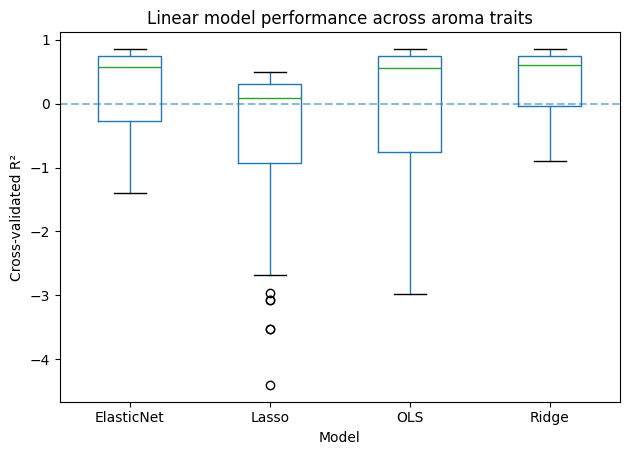

In [ ]:
plt.figure(figsize=(7, 5))
df_linear.boxplot(column="CV_R2", by="Model", grid=False)
plt.axhline(0, linestyle="--", alpha=0.5)
plt.title("Linear model performance across aroma traits")
plt.suptitle("")
plt.ylabel("Cross-validated R²")
plt.tight_layout()
plt.show()


Across traits, Ridge and ElasticNet show the most consistently strong cross-validated performance (many traits with positive R²), while Lasso and OLS are less stable and sometimes drop to strongly negative R². Overall, a subset of compounds is clearly predictable from the marker set (CV R² often ~0.6–0.8)

## Generation of predicted aroma values from selected linear models



In [ ]:

from genemarker_module import build_linear_predictions_from_best_models
dfP_linear = build_linear_predictions_from_best_models(
    best_linear=best_linear,
    gwas_file=gwas_file,
    snp_df=merged_snp_aroma,   # biorep1
    n_snps=300,
    prune_threshold=0.95
)
dfP_linear.shape

Built predictions for 67 aroma traits


(94, 67)

I use predicted aroma for linking gene_aroma_sensory

# Aroma Trait Prediction Using Kernel Ridge Regression on GWAS Markers

Across 67 aroma traits, the best-performing linear models are mostly Ridge and ElasticNet, suggesting many traits benefit from regularisation when using hundreds of SNPs. A subset of compounds shows high cross-validated performance (up to CV R² ≈ 0.81, e.g., alpha-Terpineol, (E,E)-2,4-Decadienal, 1-Octen-3-ol), while several traits are weakly predictable (near 0) or even negative (worse than a mean baseline). Compared to KRR, the linear models reach higher top-end CV R² in this run, while KRR tends to give more moderate best-case performance in Top-10 plot (~0.6 range).

In [ ]:
from genemarker_module import run_krr_models_cv_nested_light

df_krr = run_krr_models_cv_nested_light(
    gwas_file=gwas_file,
    snp_df=merged_snp_aroma,
    n_snps=300,
    prune_threshold=0.95,
    n_splits=3,
    random_state=42
)

display(df_krr.head())


,Trait,Model,CV_R2,RMSE,MAE
0,Unnamed: 0,KRR_RBF,0.077431,26.062256,22.471164
1,(E)-2-Decenal,KRR_RBF,0.574288,127640.486076,82875.303657
2,"(E, E)-2,4-Decadienal",KRR_RBF,0.631957,258953.583831,155716.112672
3,1-Heptanol,KRR_RBF,0.040496,434976.077736,199976.098252
4,1-Nonanol,KRR_RBF,0.340671,205673.036612,110834.373483


# Nonlinear Modeling of GWAS-Selected SNPs for Aroma Trait Prediction

<Figure size 700x500 with 0 Axes>

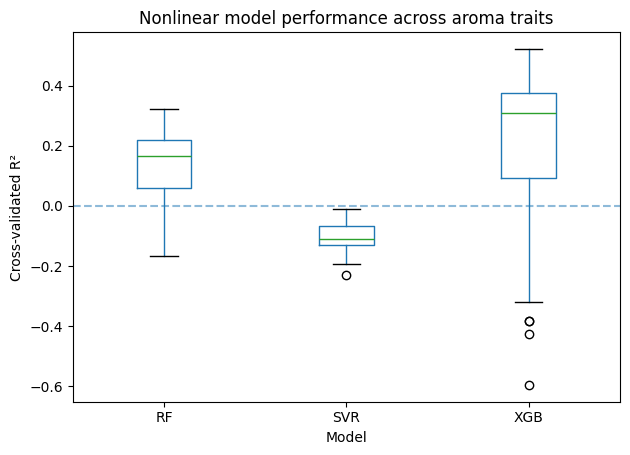

In [ ]:

from genemarker_module import  run_nonlinear_models_cv_nested_light
results_nonlinear_fast_cv = run_nonlinear_models_cv_nested_light(
    gwas_file=gwas_file,
    snp_df=merged_snp_aroma,
    n_snps=300,                
    prune_threshold=0.95,
    n_splits=3,                
    random_state=42,

)


plt.figure(figsize=(7, 5))
results_nonlinear_fast_cv.boxplot(column="CV_R2", by="Model", grid=False)
plt.axhline(0, linestyle="--", alpha=0.5)
plt.title("Nonlinear model performance across aroma traits")
plt.suptitle("")
plt.ylabel("Cross-validated R²")
plt.tight_layout()
plt.show() 


In [ ]:
best_nonlinear = (
    results_nonlinear_fast_cv
    .groupby("Trait", as_index=False)
    .agg(
        CV_R2_mean=("CV_R2", "mean"),
        RMSE_mean=("RMSE", "mean"),
        MAE_mean=("MAE", "mean")
    )
)
best_nonlinear

,Trait,CV_R2_mean,RMSE_mean,MAE_mean
0,(E)-2-Decenal,0.183147,1.757831e+05,1.129294e+05
1,"(E, E)-2,4-Decadienal",0.077873,4.083125e+05,2.118622e+05
2,1-Heptanol,0.158489,4.046004e+05,1.971348e+05
3,1-Nonanol,0.212475,2.214563e+05,1.233160e+05
4,1-Octen-3-ol,0.203098,9.561160e+04,6.259597e+04
...,...,...,...,...
62,Tridecane,0.033499,3.489532e+05,8.477948e+04
63,Undecanal,0.072911,9.759085e+05,5.748258e+05
64,Unnamed: 0,0.060853,2.621969e+01,2.251421e+01
65,alpha-Terpineol,0.129558,6.261541e+05,3.464495e+05


Across the 67 aroma traits, the nonlinear models show mostly modest cross-validated performance. In the boxplot, XGBoost has the highest median CV R² and the widest spread (some traits improve clearly, but there are also negative outliers), Random Forest sits in the middle with generally small positive CV R², and SVR performs weakest overall with CV R² often near or below zero. And weaker than both linear and KRR

# Correlation of gene-based aroma predictions with sensory principal components


 Using 67 genetically predicted traits for correlation
 Matched samples for correlation: 94
 Correlation matrix saved to: results/sensory_integration\linear_gene_predicted_sensory_correlation_linear_biorep1.csv


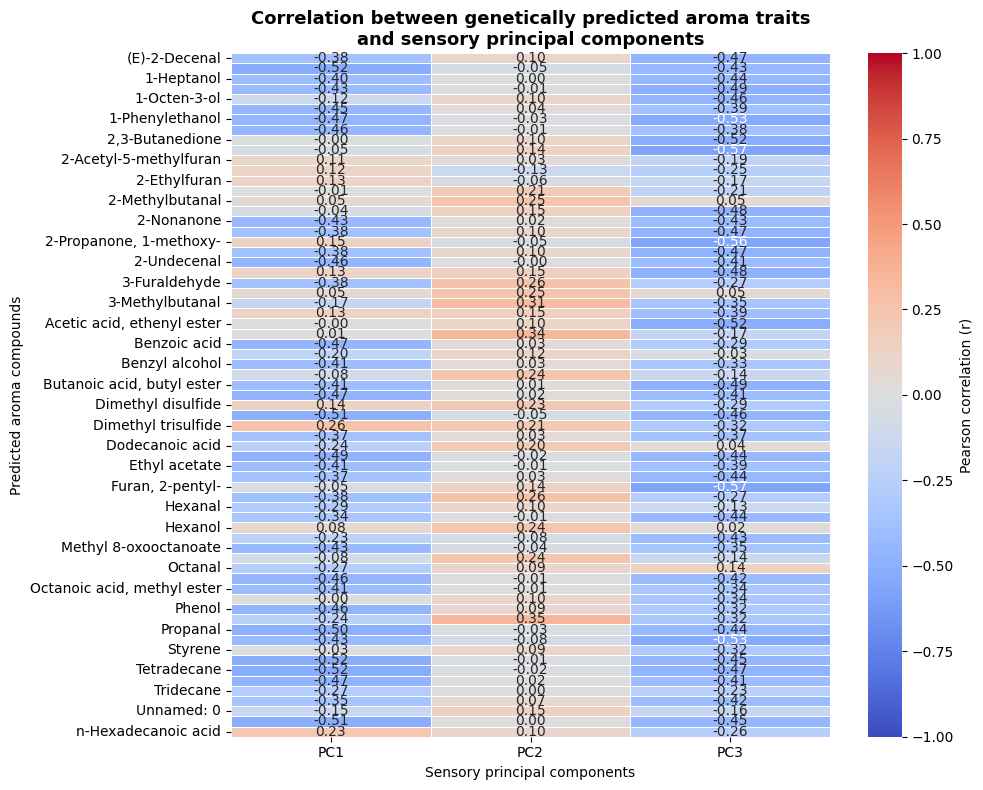

In [ ]:

from genemarker_module import correlate_gene_predictions_with_sensory_pcs

corr_linear_sensory = correlate_gene_predictions_with_sensory_pcs(
    predictions_df=dfP_linear,
    merged_snp_sensory=merged_snp_sensory,
    save_dir="results/sensory_integration",
    r2_threshold=0.5,
    tag="linear_biorep1"
)



plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_linear_sensory,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    cbar_kws={"label": "Pearson correlation (r)"}
)

plt.title(
    "Correlation between genetically predicted aroma traits\nand sensory principal components",
    fontsize=13,
    weight="bold"
)
plt.xlabel("Sensory principal components")
plt.ylabel("Predicted aroma compounds")

plt.tight_layout()
plt.show()



This heatmap shows how genetically predicted aroma compounds align with the main sensory axes (PC1–PC3). For example, compounds such as n-Hexadecanoic acid, dimethyl sulfide, and dimethyl trisulfide show positive correlations with PC1, suggesting they align with the positive PC1 sensory direction, which in our PCA space is associated with more sour/bitter attributes.

# Linking GWAS-prioritised SNPs to aroma compounds and sensory PCs



Top gene-predicted compounds associated with sensory PCs:


Propanoic acid           0.345152
1-Phenylethanol          0.342681
Dimethyl phthalate       0.341452
Tetradecane              0.339311
(E, E)-2,4-Decadienal    0.336296
dtype: float64


Triangle built for 5 compounds


,Gene (SNP),Compound,Sensory PC,Compound–Sensory Corr
0,GEN__437034,Propanoic acid,PC3,-0.53181
1,GEN__437035,Propanoic acid,PC3,-0.53181
2,GEN__437036,Propanoic acid,PC3,-0.53181
3,GEN__344921,Propanoic acid,PC3,-0.53181
4,GEN__345071,Propanoic acid,PC3,-0.53181


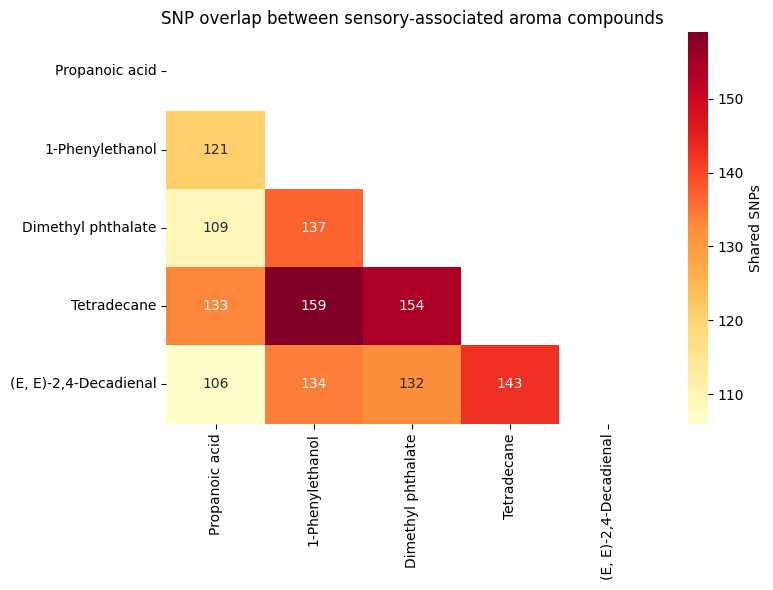

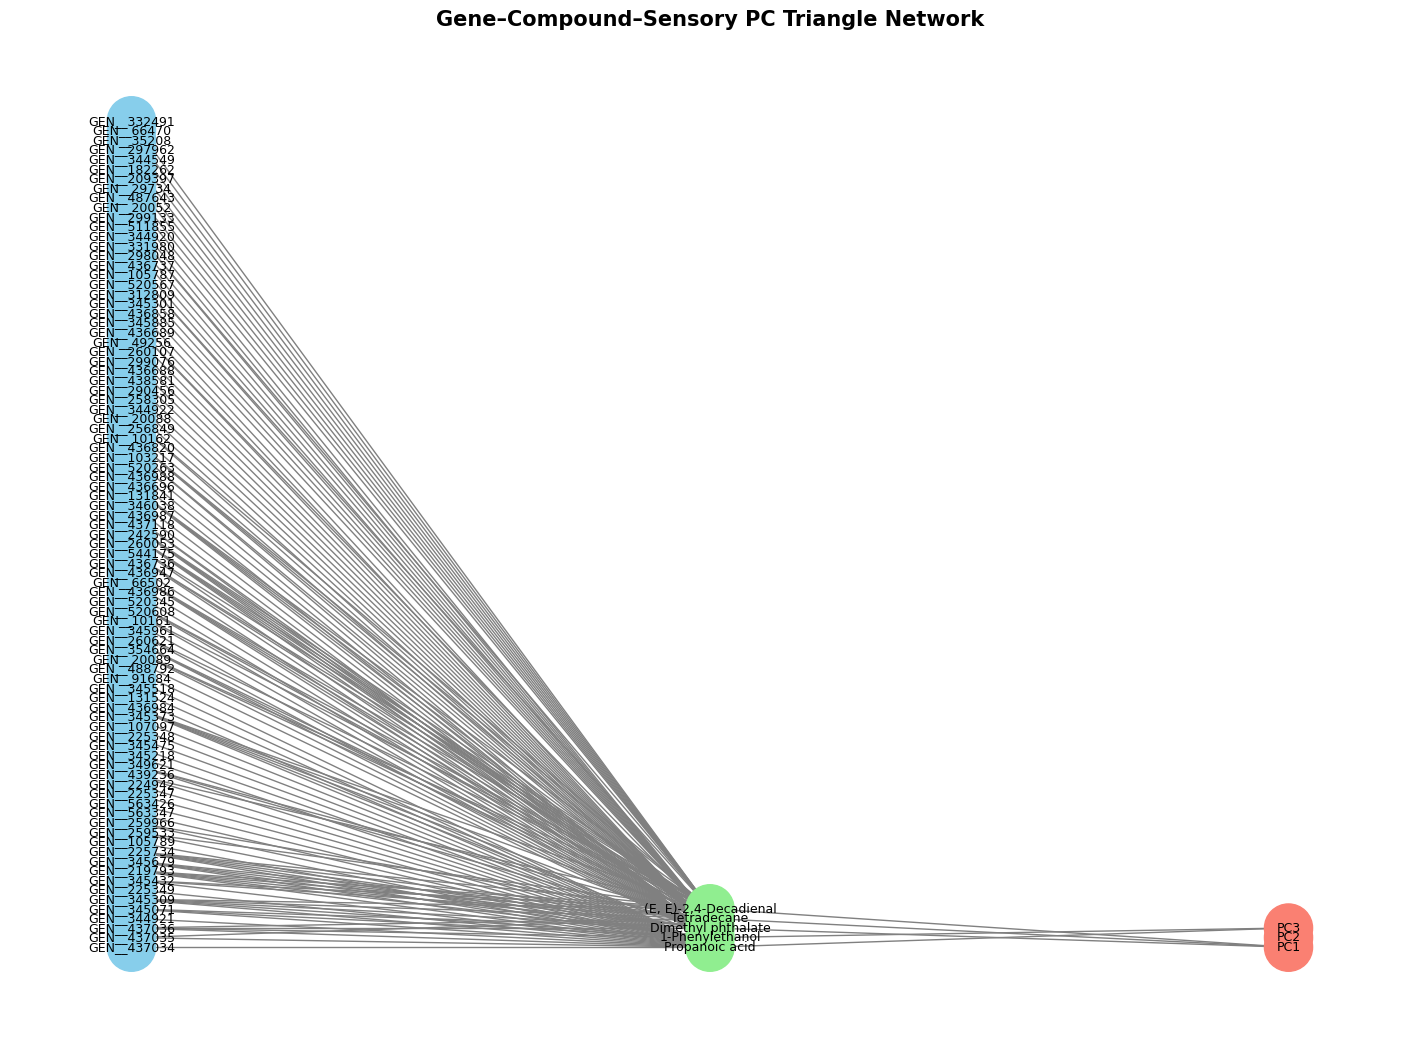

In [ ]:

from genemarker_module import build_gene_compound_sensory_triangle

triangle_df, overlap_matrix = build_gene_compound_sensory_triangle(
    gwas_file=gwas_file,
    corr_matrix=corr_linear_sensory,
    corr_threshold=0.3,          
    top_compounds=5,             
    top_snps_per_compound=500,   
    network_snps_per_compound=30,# 
    save_dir="results/gene_compound_sensory_triangle"
)


The network suggests a genotype → aroma compound → sensory PC link: the top 5 compounds are the strongest sensory-aligned signals, and many SNPs connect to them.

The overlap heatmap shows large shared SNP sets (~100–160) between compounds, implying shared loci/LD blocks (possible pleiotropy) rather than fully independent genetic control

## Summarising marker effects for top correlated aroma traits



 Found 67 high-correlation compounds (|r| ≥ 0.1):
→ ['2,4-Heptadienal', 'Furan, 2-pentyl-', '2-Propanone, 1-methoxy-', '1-Phenylethanol', 'Propanoic acid', '(E, E)-2,4-Decadienal', 'Tetradecane', 'Tetradecanal', '2,3-Butanedione', 'Acetic acid, ethenyl ester', 'alpha-Terpineol', 'Dimethyl phthalate', 'Propanal', '1-Nonanol', 'Butanoic acid, butyl ester', 'Ethanol, 2-phenoxy-', '2-Methylpropanal', '3-Carene', 'Decanal', 'Tridecanal', '(E)-2-Decenal', '2-Tridecenal', '2-Nonenal, (E)-', 'Benzoic acid', 'Octanoic acid', 'Phenol', '2(3H)-Furanone, dihydro-5-pentyl-', '2-Undecenal', '1-Octen-3-ol', '1-Penten-3-one', 'Ethyl butanoate', '1-Heptanol', 'Hexanoic acid', 'Methyl 8-oxooctanoate', '2-Nonanone', 'Methional', 'Undecanal', 'Benzyl alcohol', 'Ethyl acetate', 'Octanoic acid, methyl ester', '6-Methyl-5-hepten-2-one', 'Furfural', '3-Furaldehyde', 'Dodecanal', '3-Methylbutanal', 'Phenylacetaldehyde', 'Pentanal', 'Acetic acid, methyl ester', 'Styrene', 'Dimethyl trisulfide', 'Hexanal', 'Dim

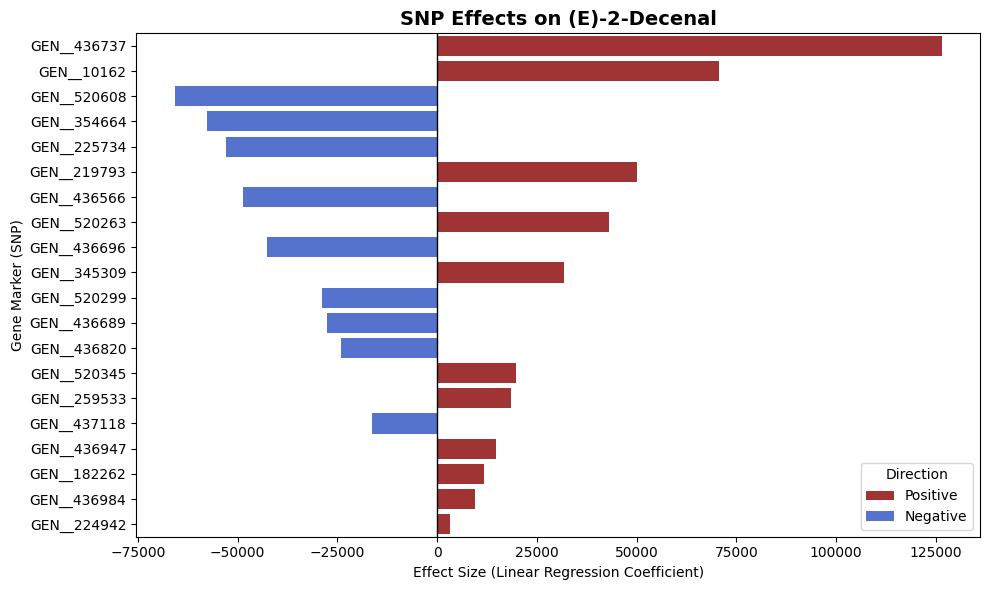


 Analyzing (E, E)-2,4-Decadienal (20 SNPs)...


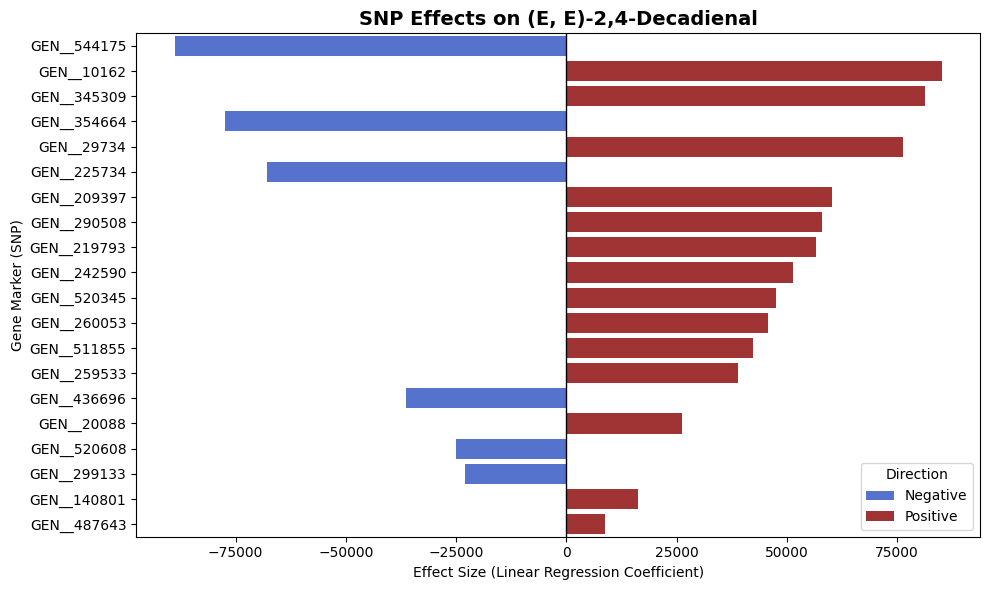


 Analyzing 1-Heptanol (20 SNPs)...


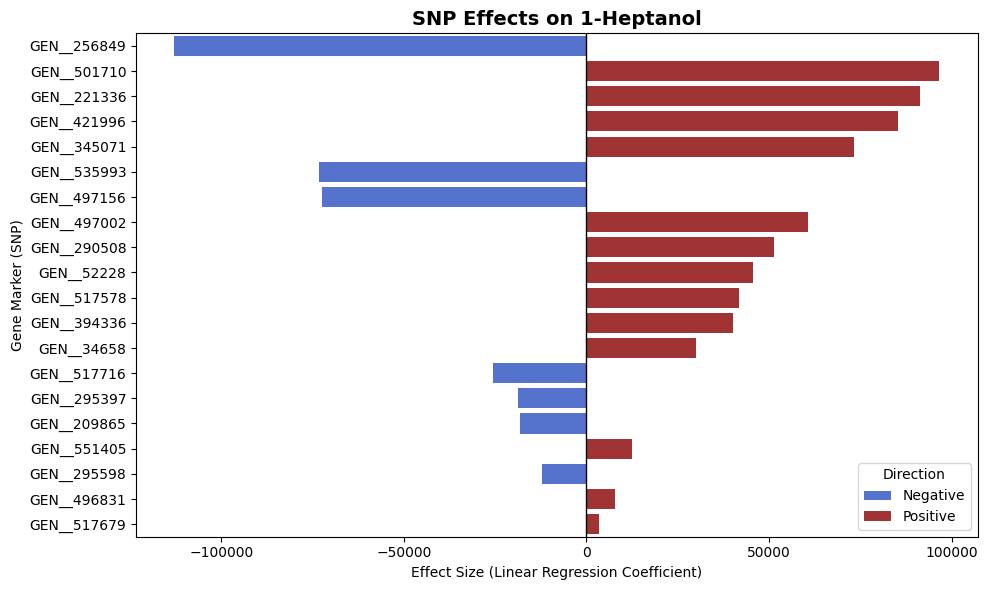


 Analyzing 1-Nonanol (20 SNPs)...


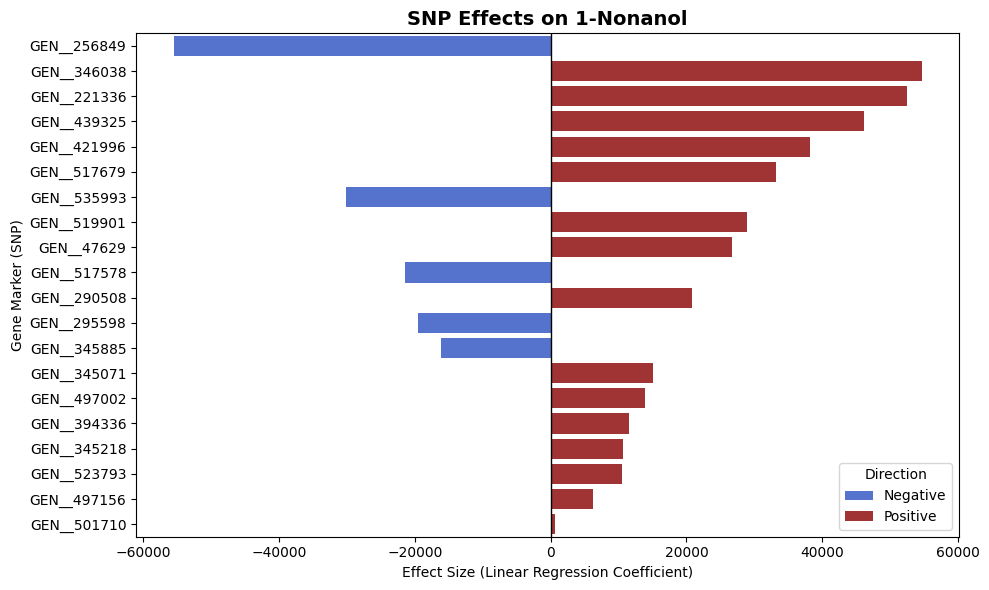


 Analyzing 1-Octen-3-ol (20 SNPs)...


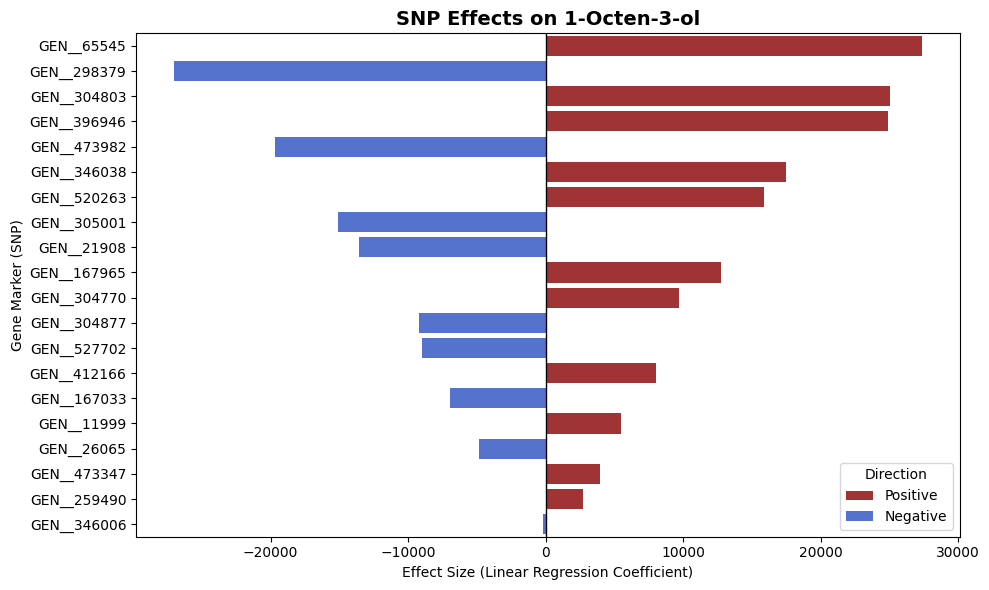


 Analyzing 1-Penten-3-one (20 SNPs)...


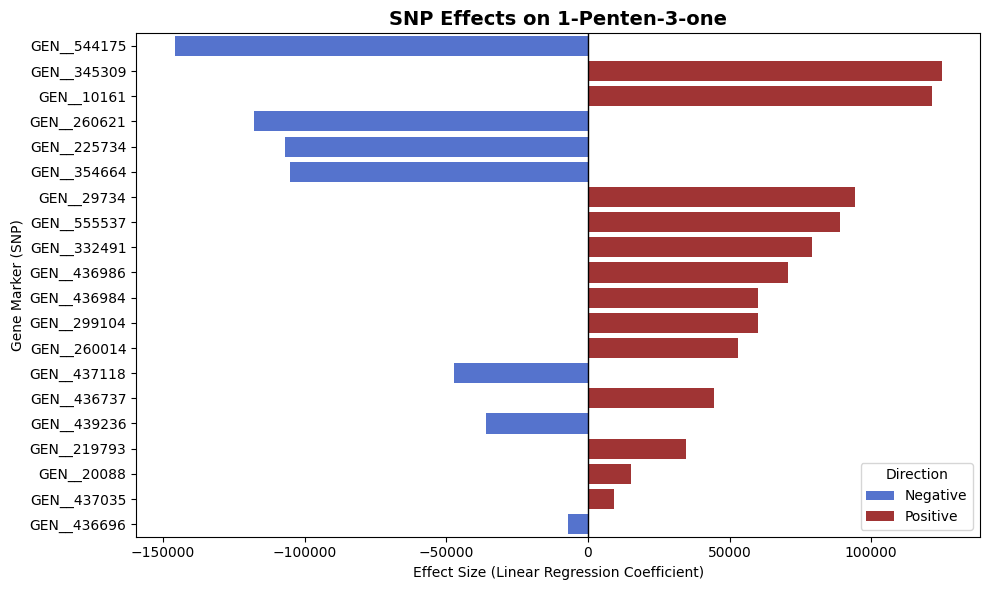


 Analyzing 1-Phenylethanol (20 SNPs)...


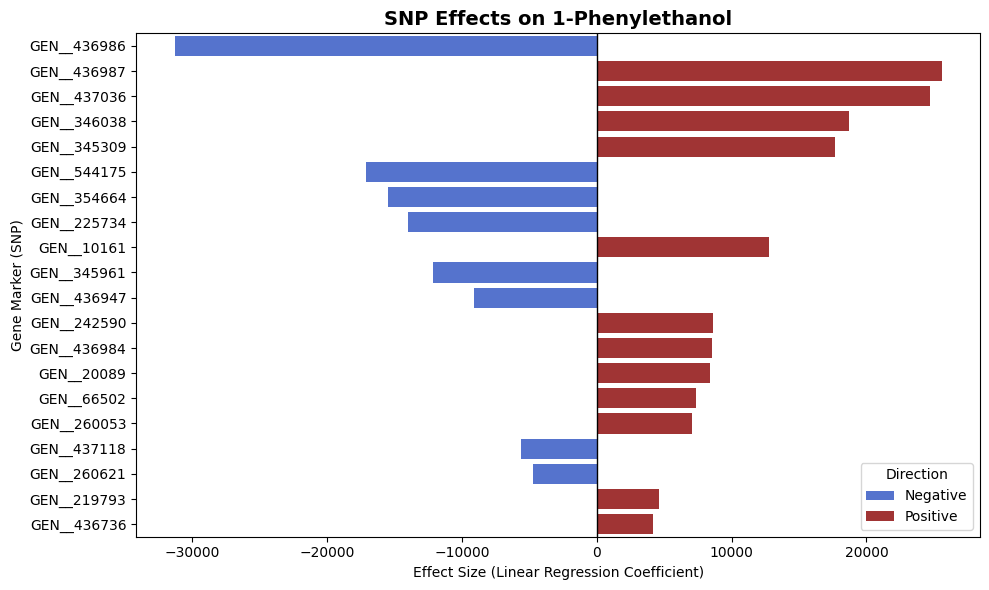


 Analyzing 2(3H)-Furanone, dihydro-5-pentyl- (20 SNPs)...


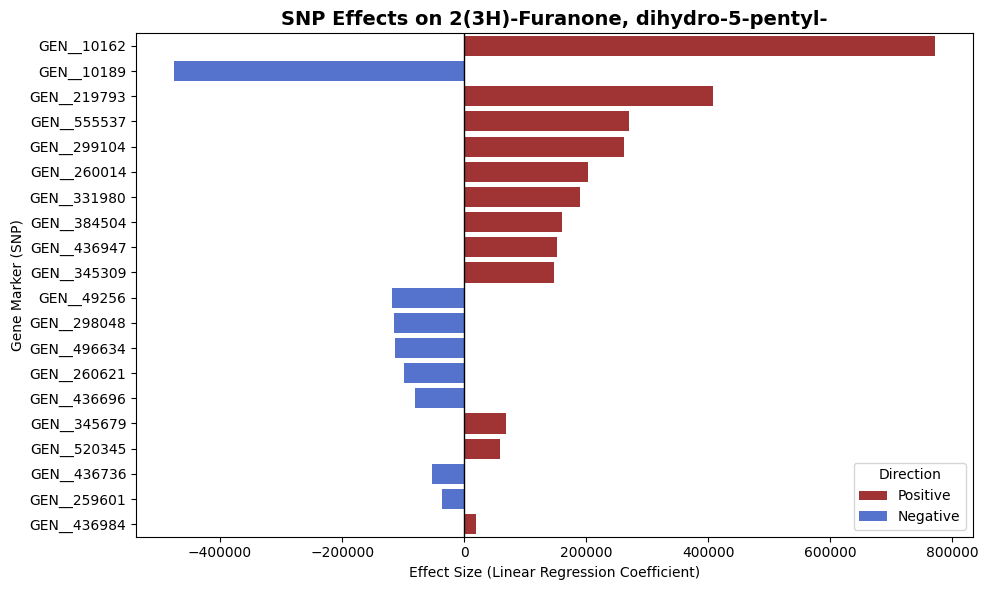


 Analyzing 2,3-Butanedione (20 SNPs)...


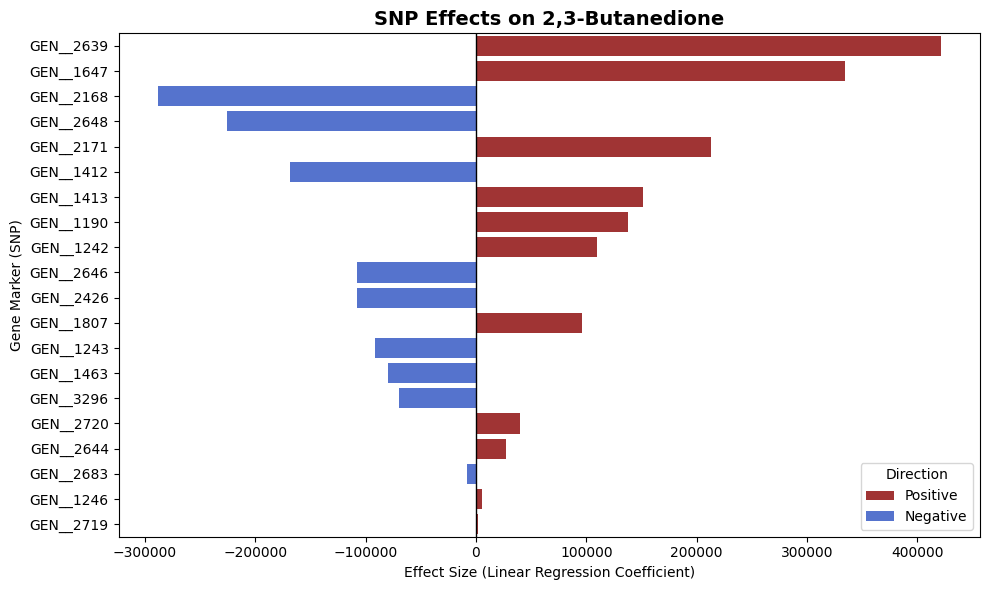


 Analyzing 2,4-Heptadienal (20 SNPs)...


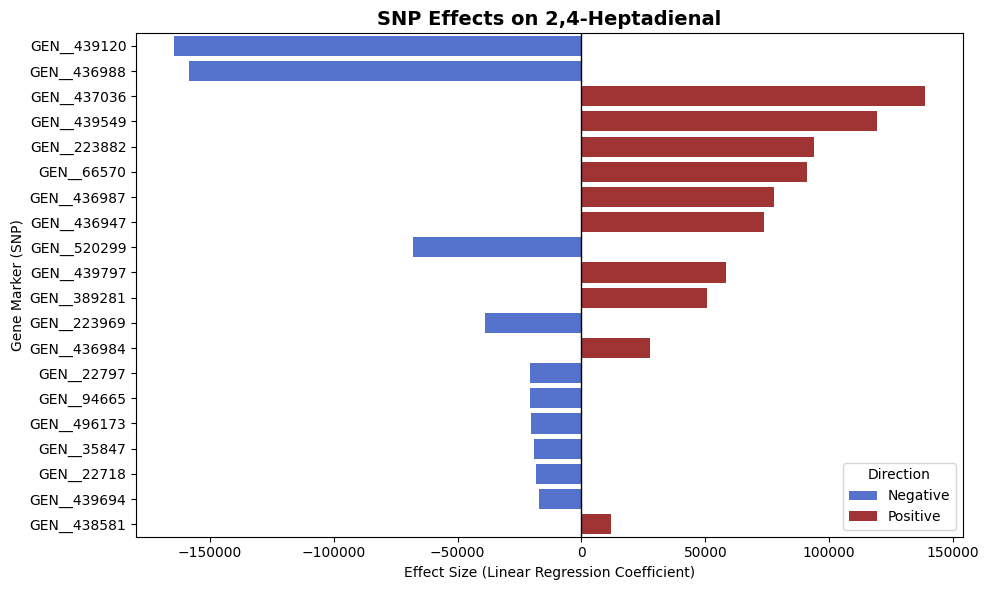


 Analyzing 2-Acetyl-5-methylfuran (20 SNPs)...


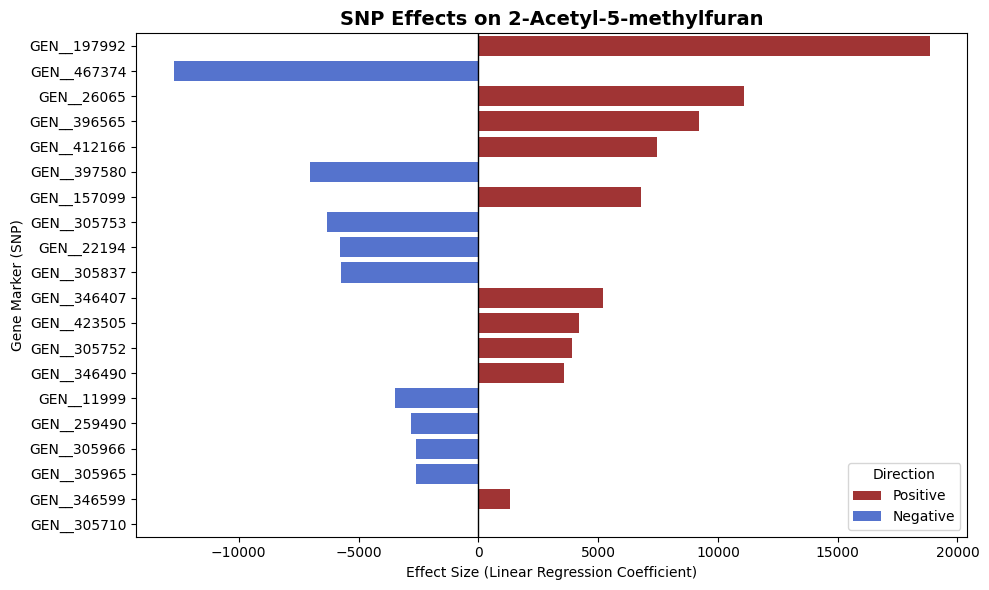


 Analyzing 2-Decanone (20 SNPs)...


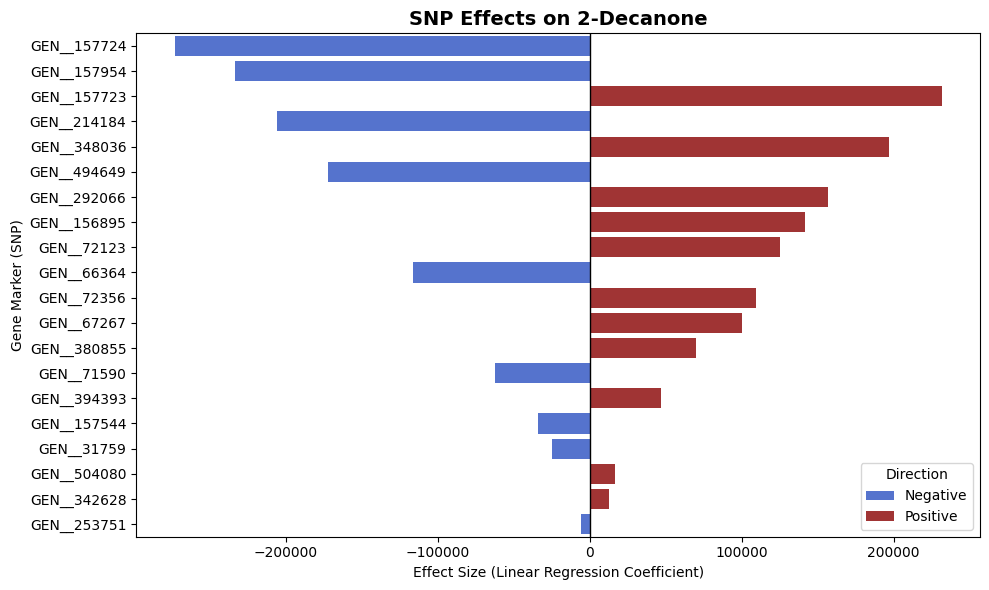


 Analyzing 2-Ethylfuran (20 SNPs)...


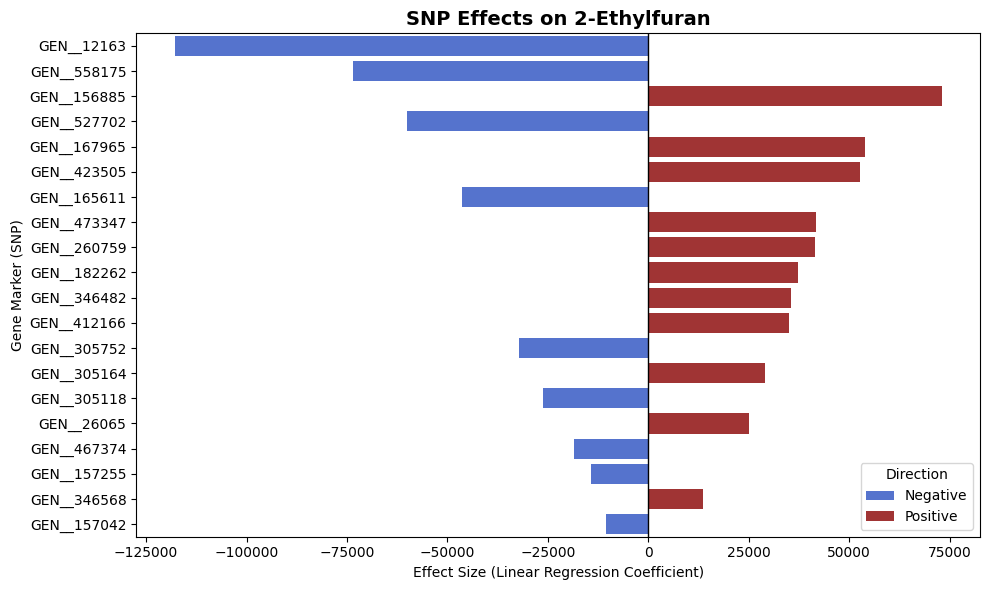


 Analyzing 2-Heptanone (20 SNPs)...


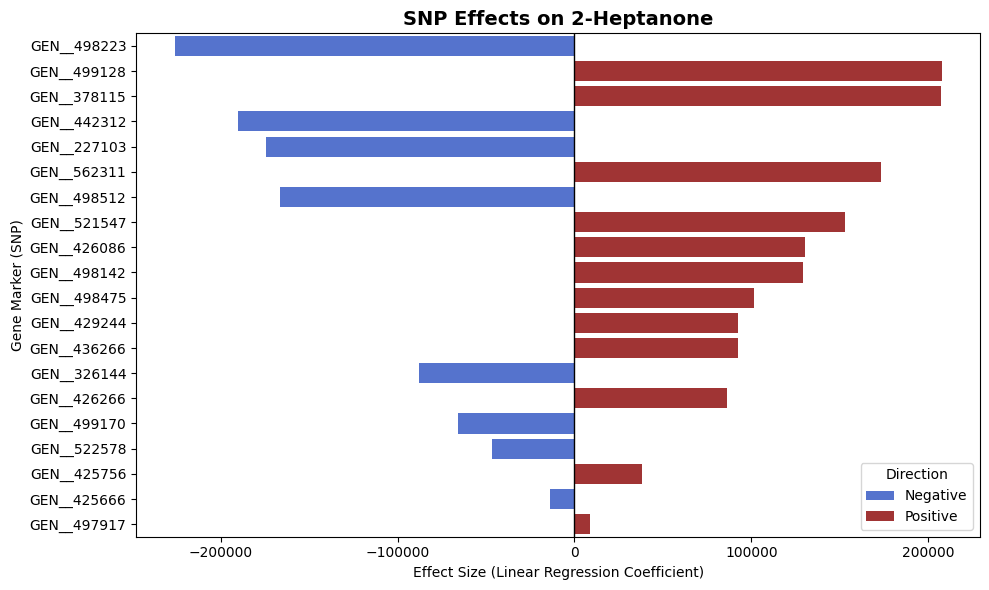


 Analyzing 2-Methylbutanal (20 SNPs)...


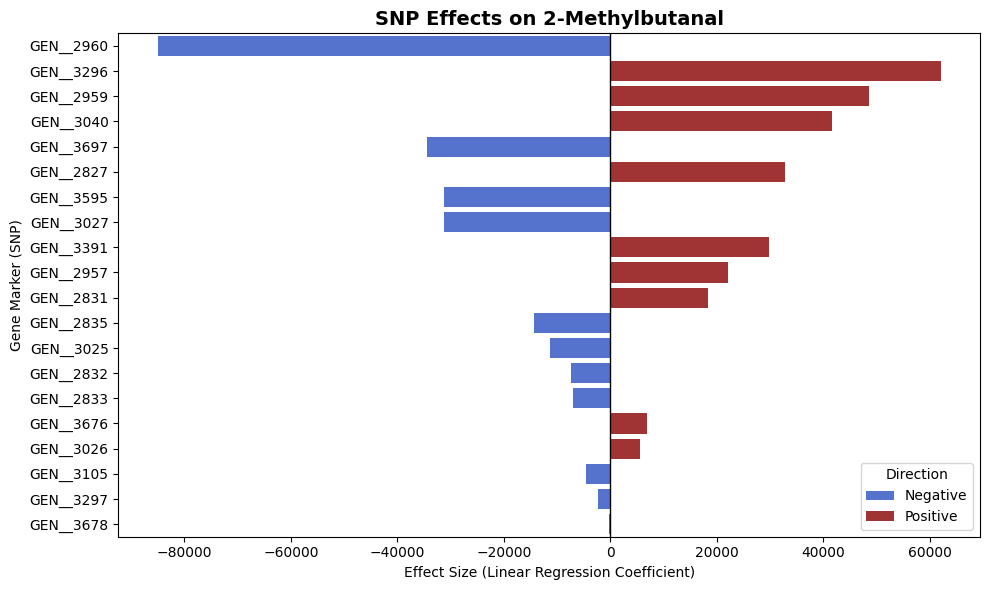


 Analyzing 2-Methylpropanal (20 SNPs)...


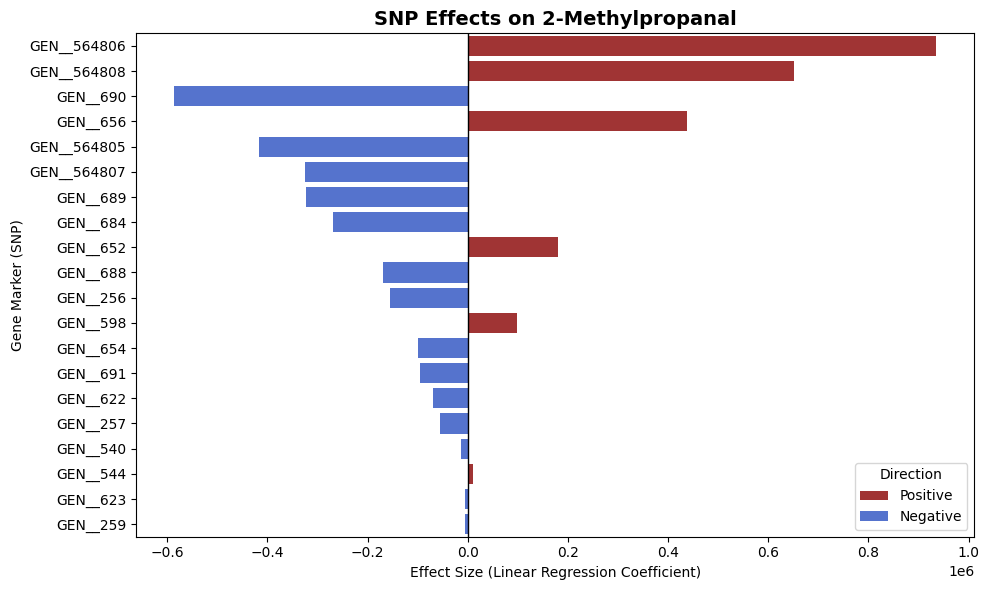


 Analyzing 2-Nonanone (20 SNPs)...


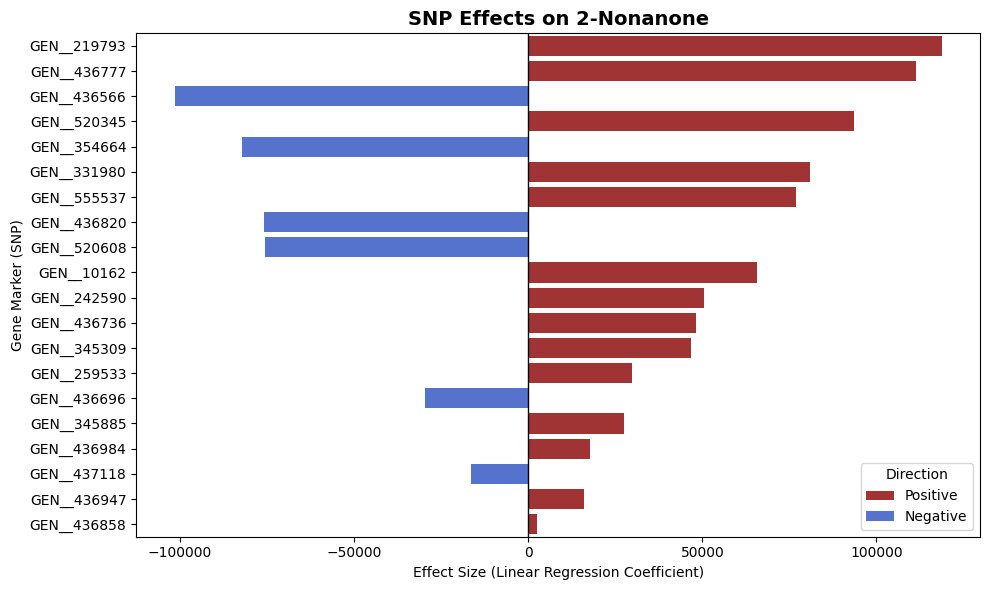


 Analyzing 2-Nonenal, (E)- (20 SNPs)...


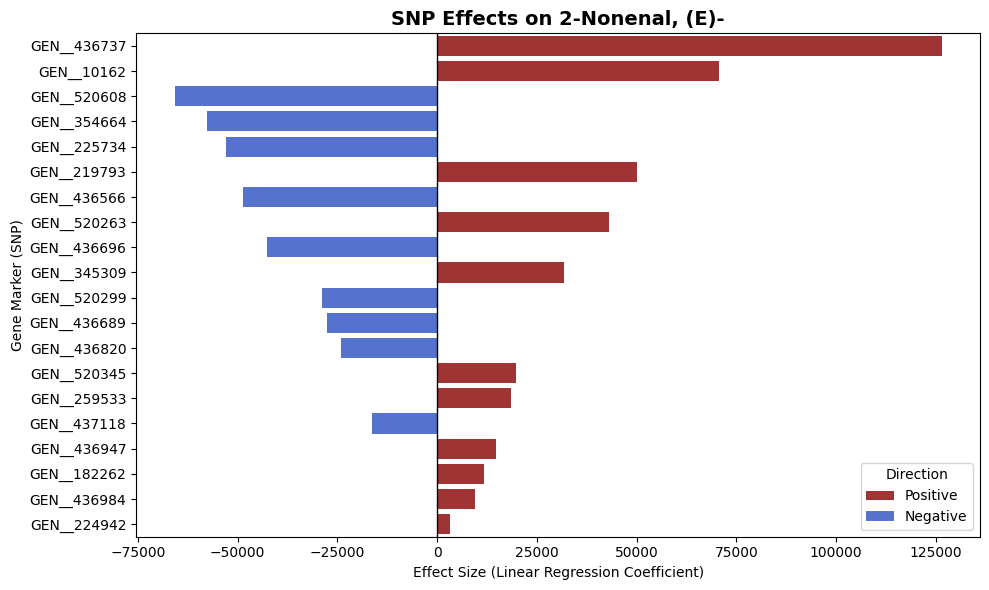


 Analyzing 2-Propanone, 1-methoxy- (20 SNPs)...


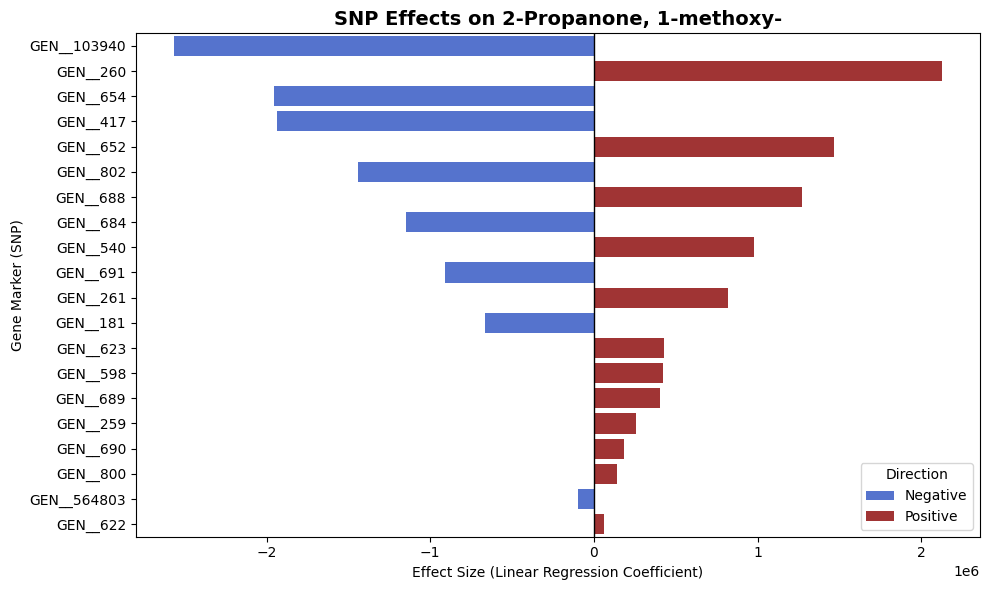


 Analyzing 2-Tridecenal (20 SNPs)...


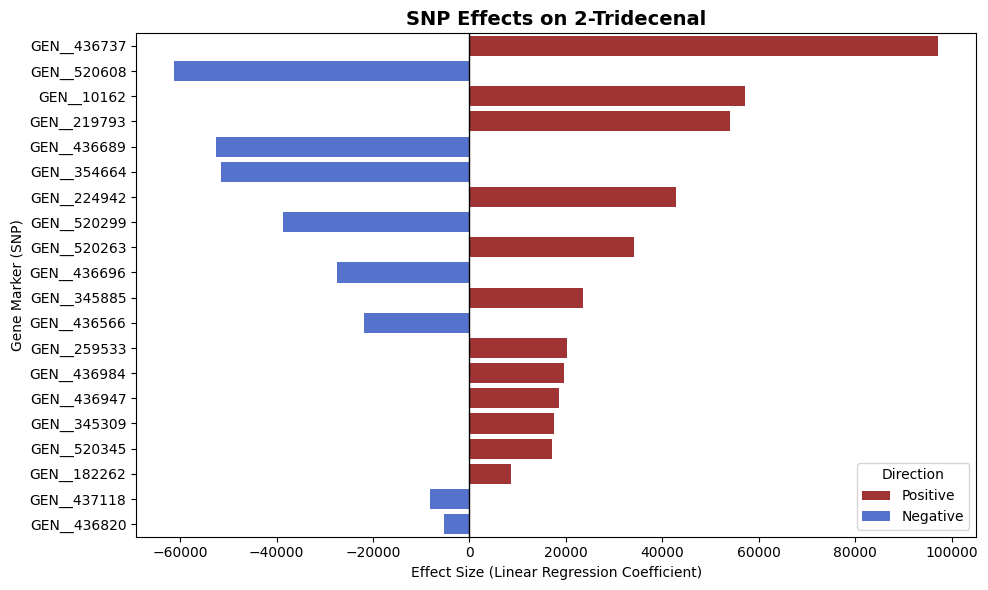


 Analyzing 2-Undecenal (20 SNPs)...


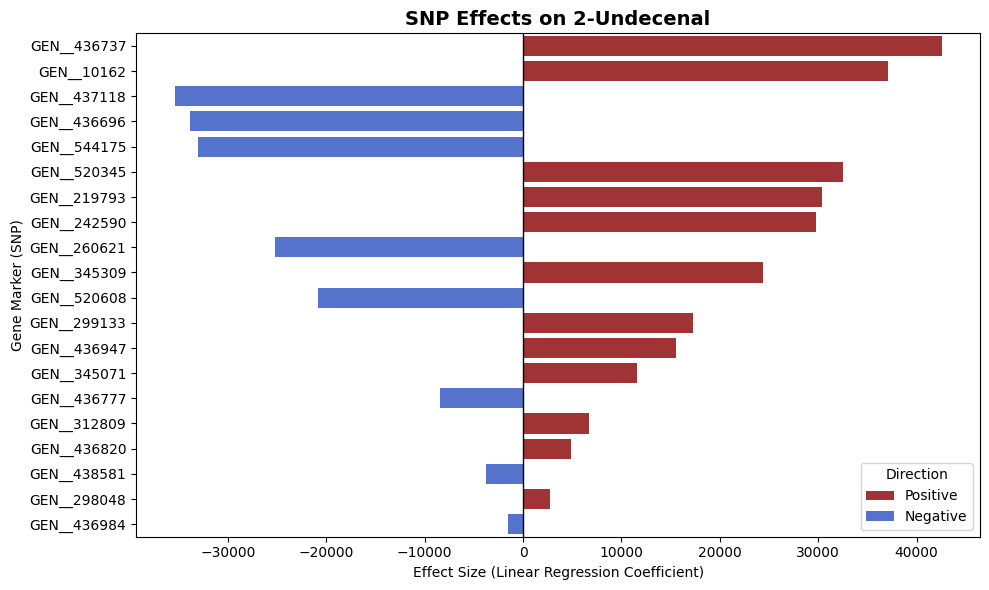


 Analyzing 3-Carene (20 SNPs)...


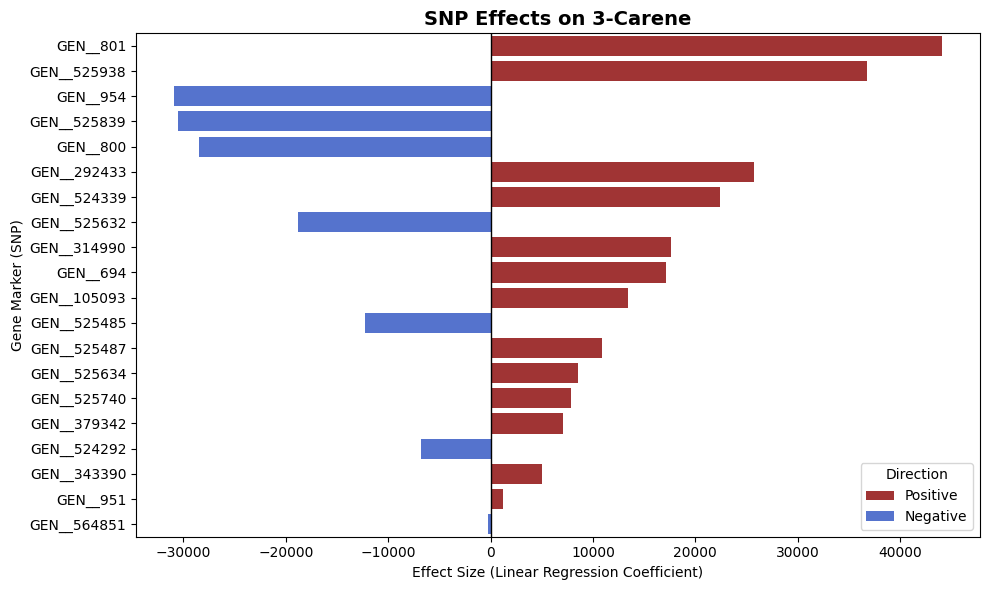


 Analyzing 3-Furaldehyde (20 SNPs)...


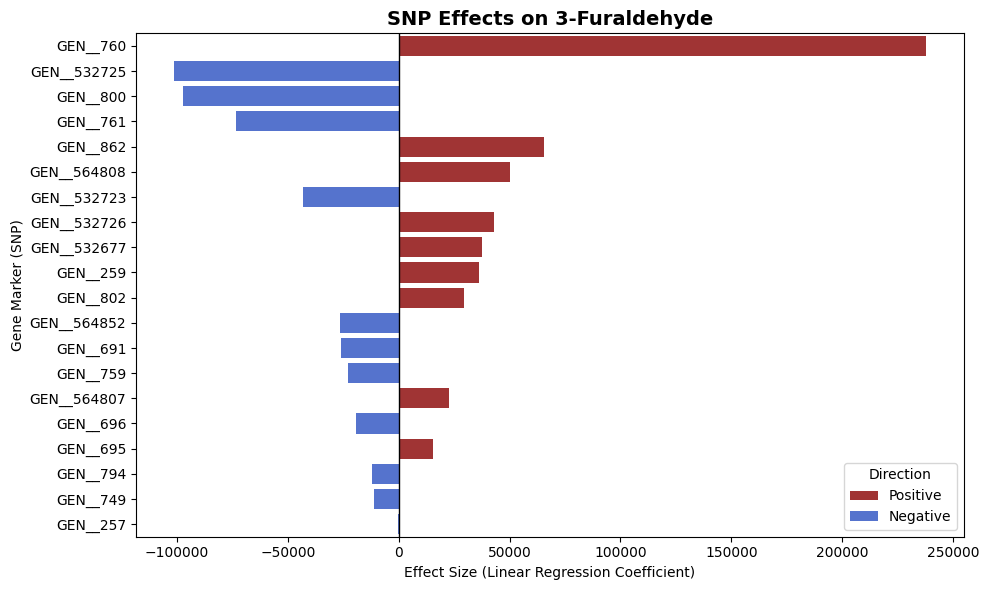


 Analyzing 3-Heptanone (20 SNPs)...


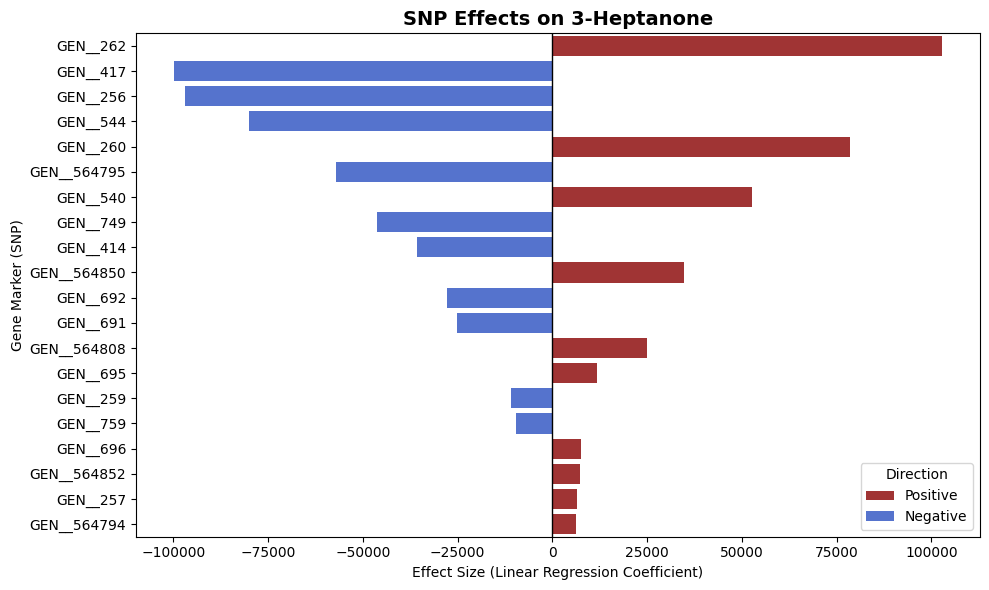


 Analyzing 3-Methylbutanal (20 SNPs)...


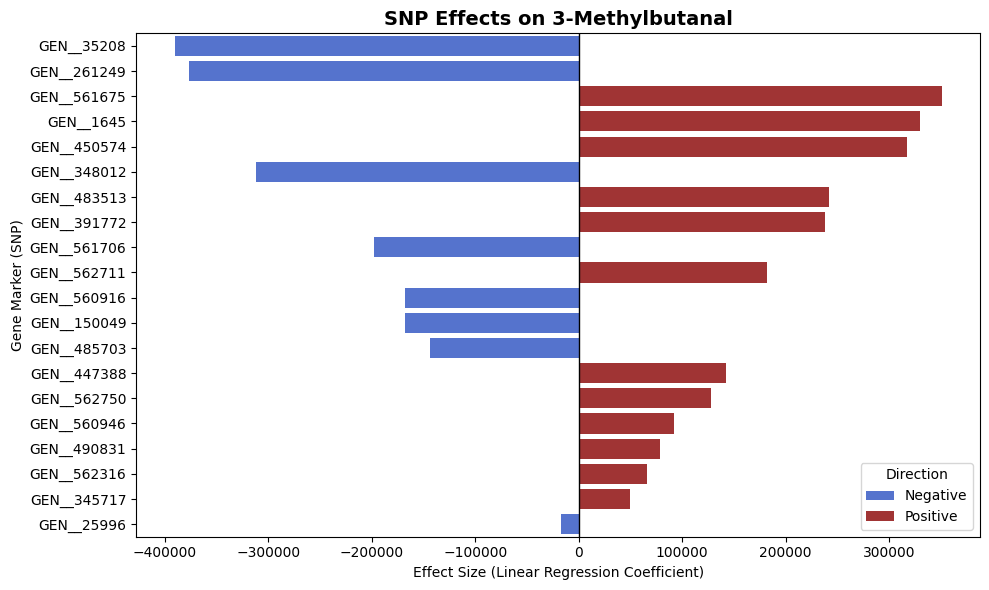


 Analyzing 6-Methyl-5-hepten-2-one (20 SNPs)...


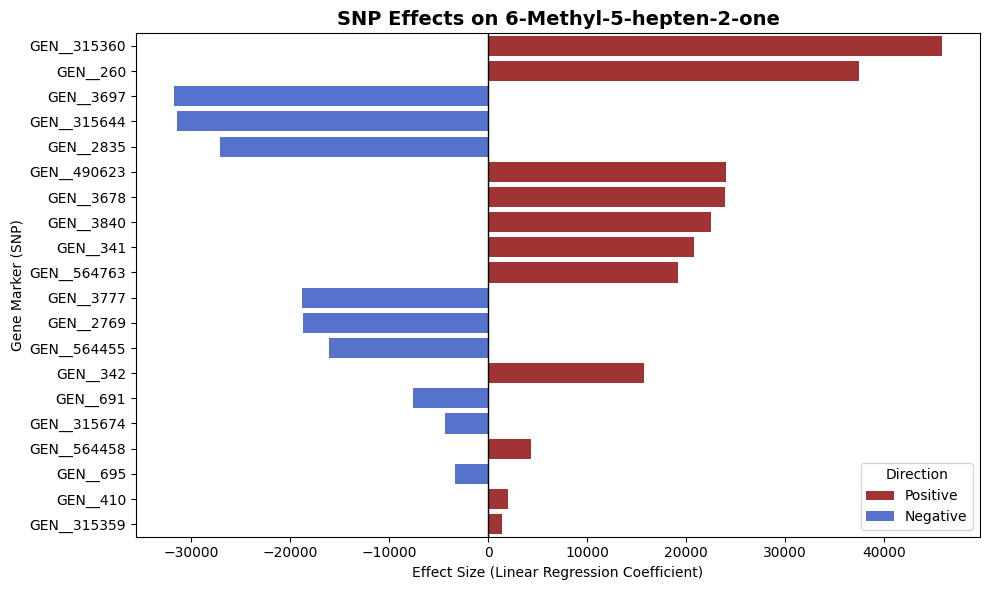


 Analyzing Acetic acid, ethenyl ester (20 SNPs)...


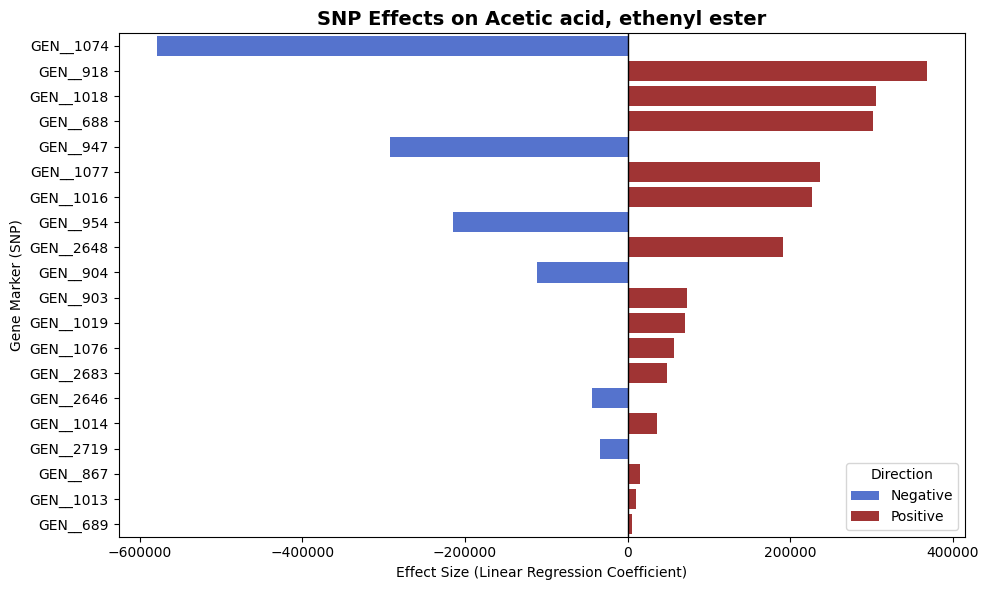


 Analyzing Acetic acid, methyl ester (20 SNPs)...


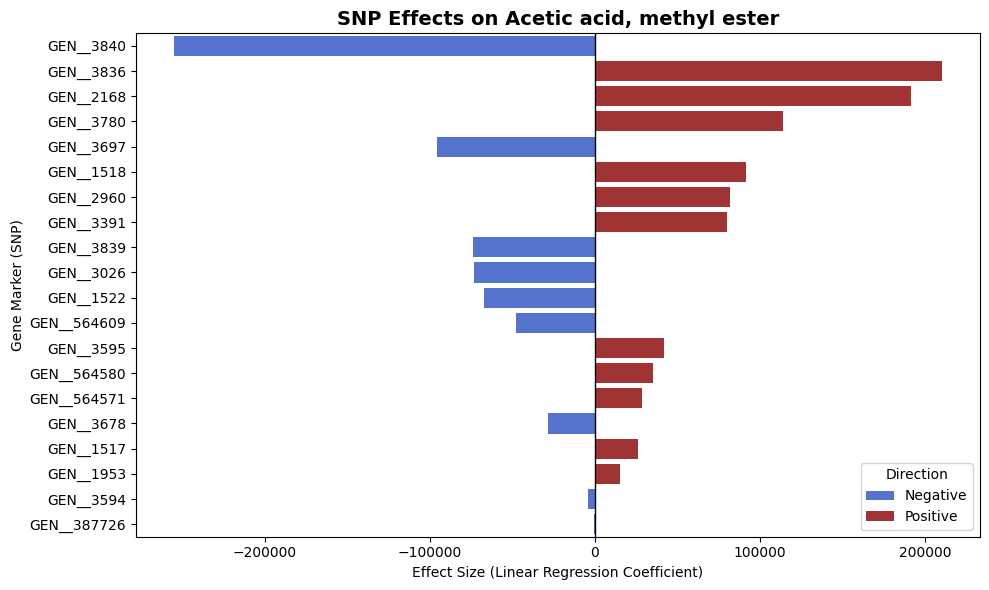


 Analyzing Benzoic acid (20 SNPs)...


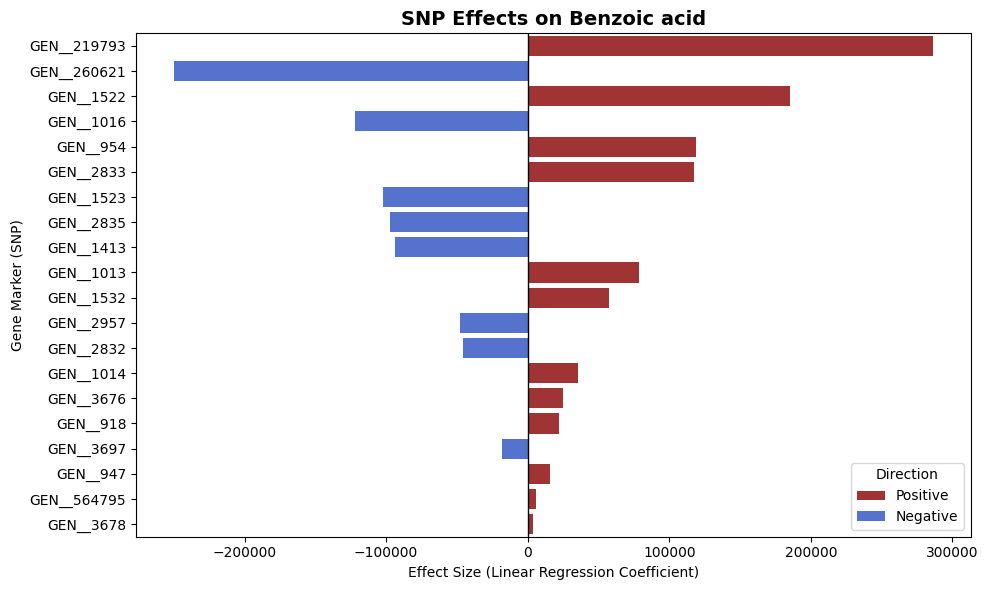


 Analyzing Benzoic acid, methyl ester (20 SNPs)...


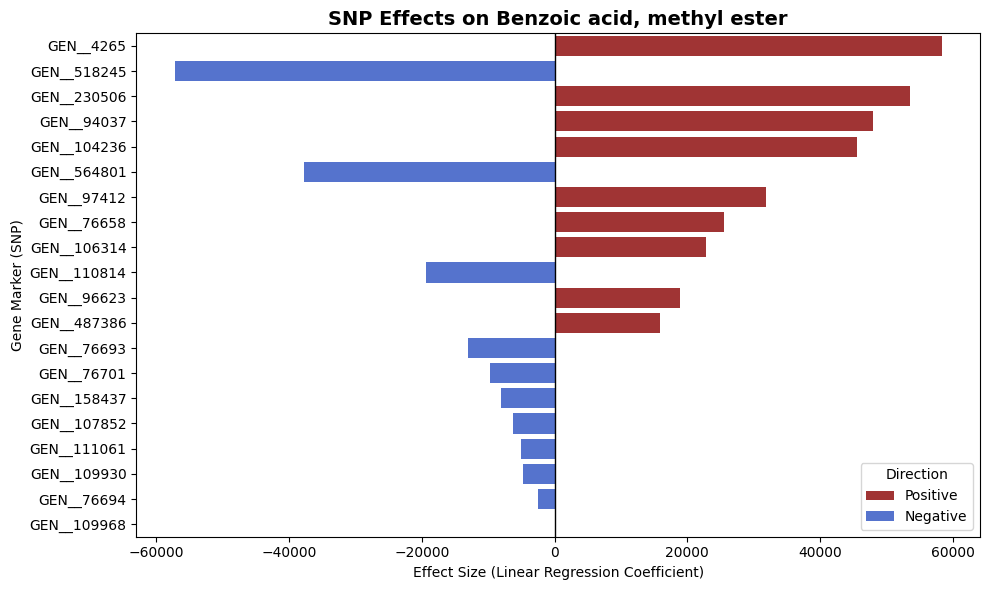


 Analyzing Benzyl alcohol (20 SNPs)...


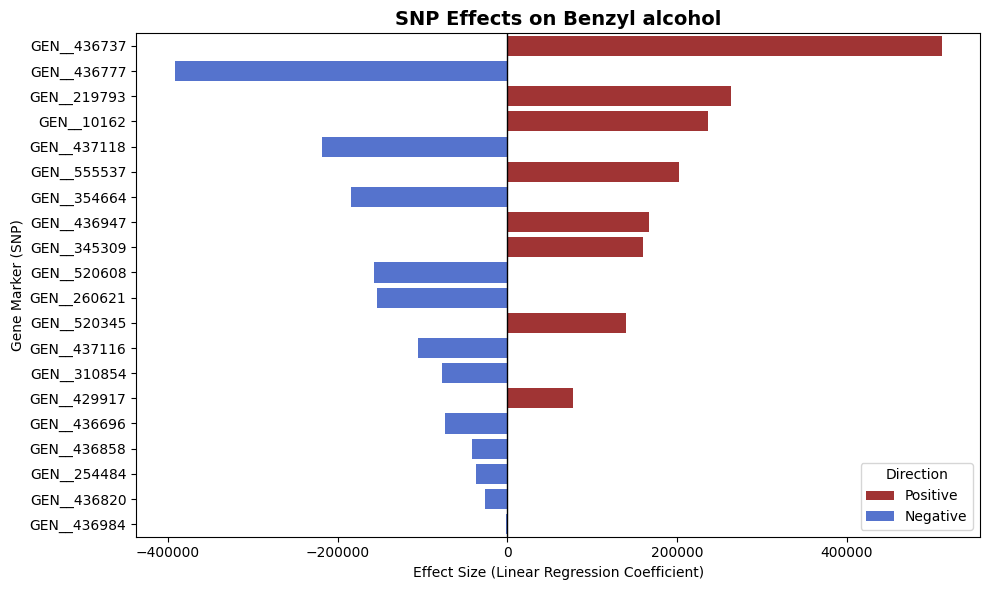


 Analyzing Butanal, 3-methyl- (20 SNPs)...


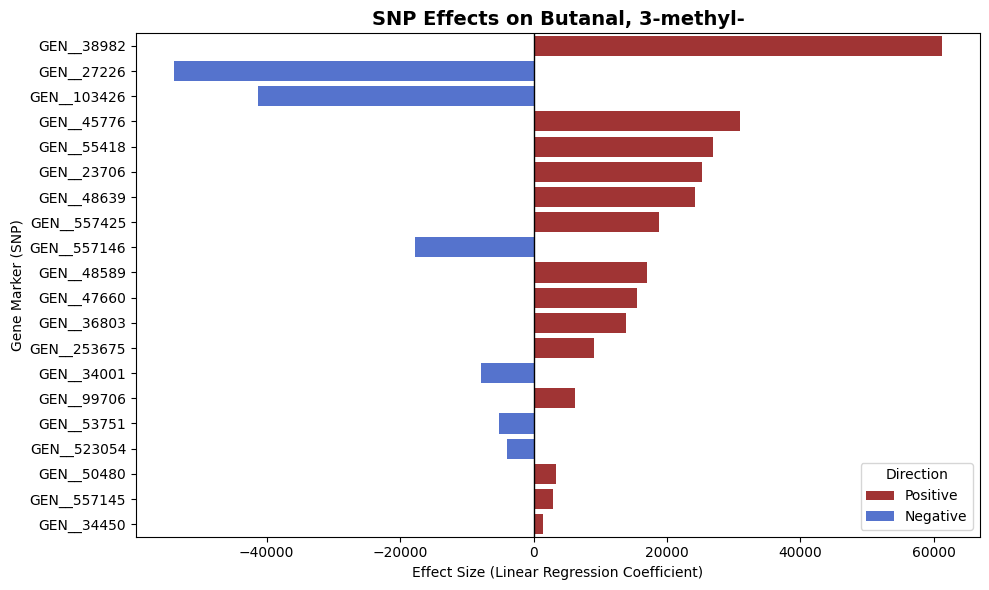


 Analyzing Butanoic acid, butyl ester (20 SNPs)...


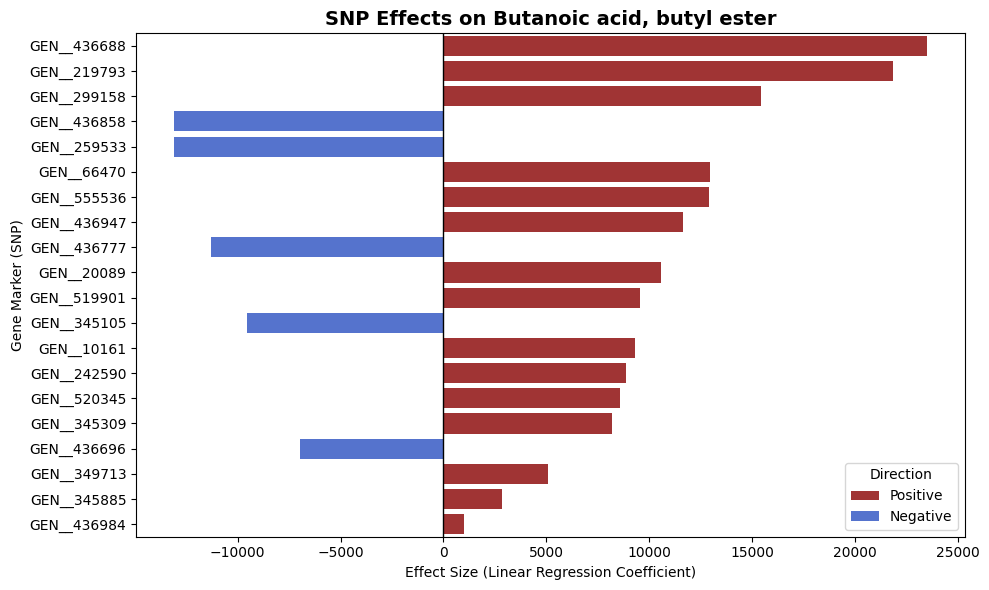


 Analyzing Decanal (20 SNPs)...


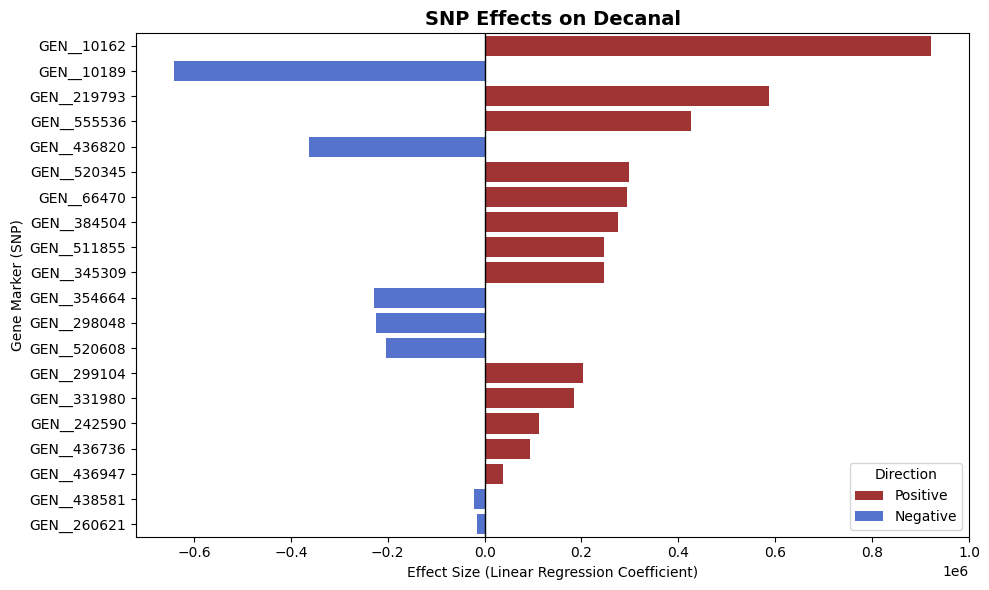


 Analyzing Dimethyl disulfide (20 SNPs)...


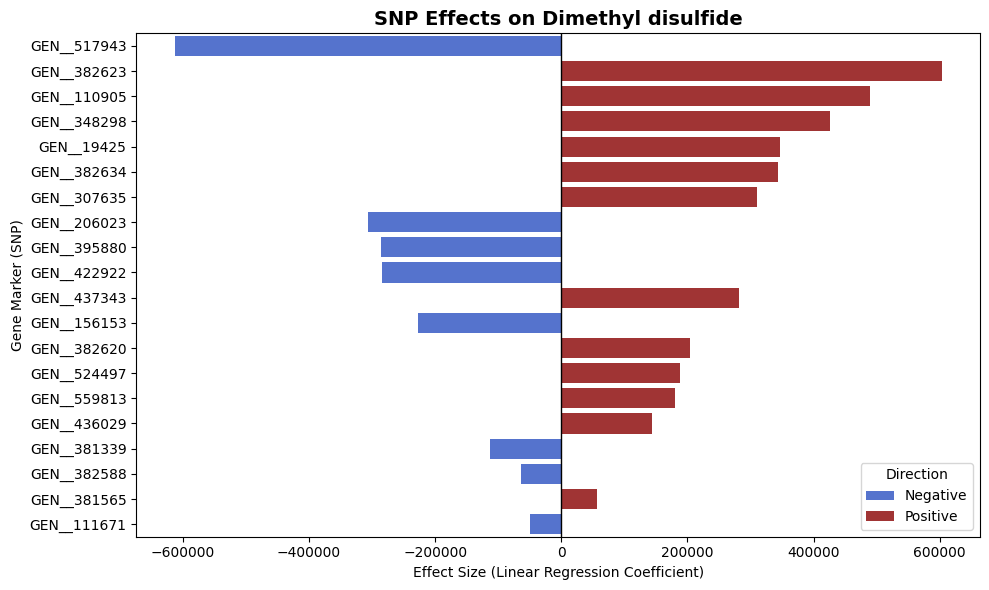


 Analyzing Dimethyl phthalate (20 SNPs)...


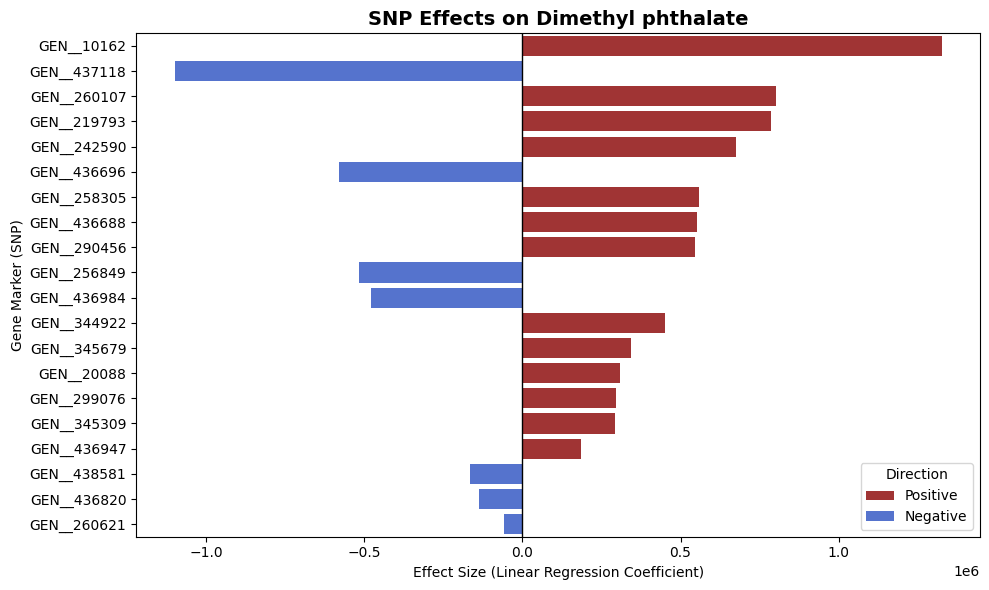


 Analyzing Dimethyl trisulfide (20 SNPs)...


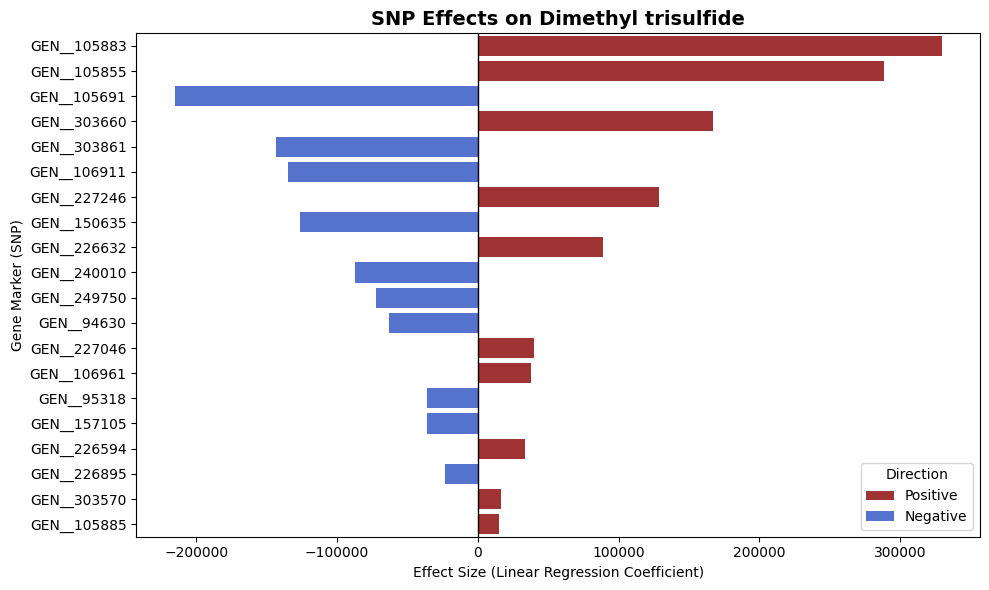


 Analyzing Dodecanal (20 SNPs)...


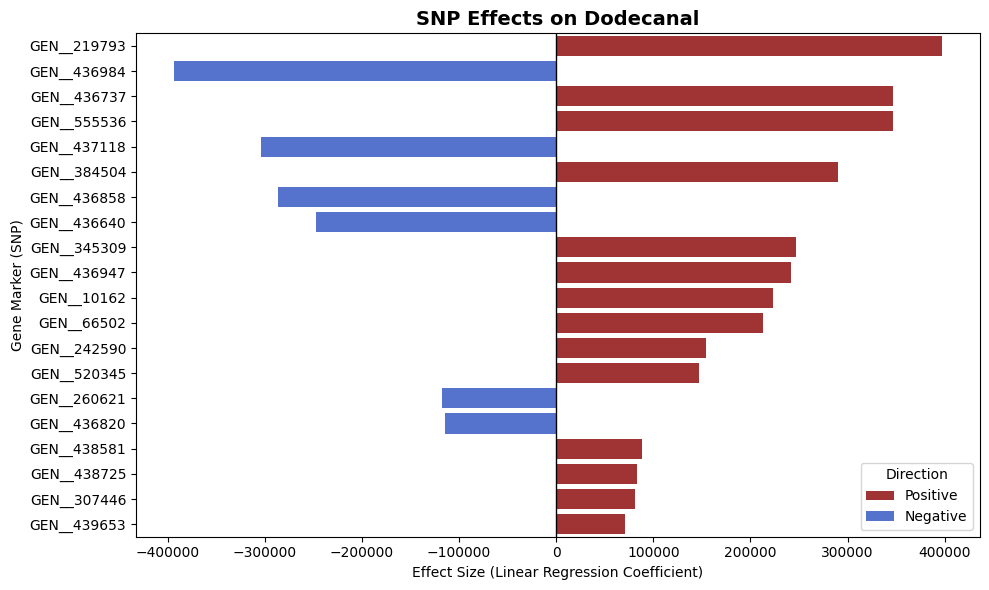


 Analyzing Dodecanoic acid (20 SNPs)...


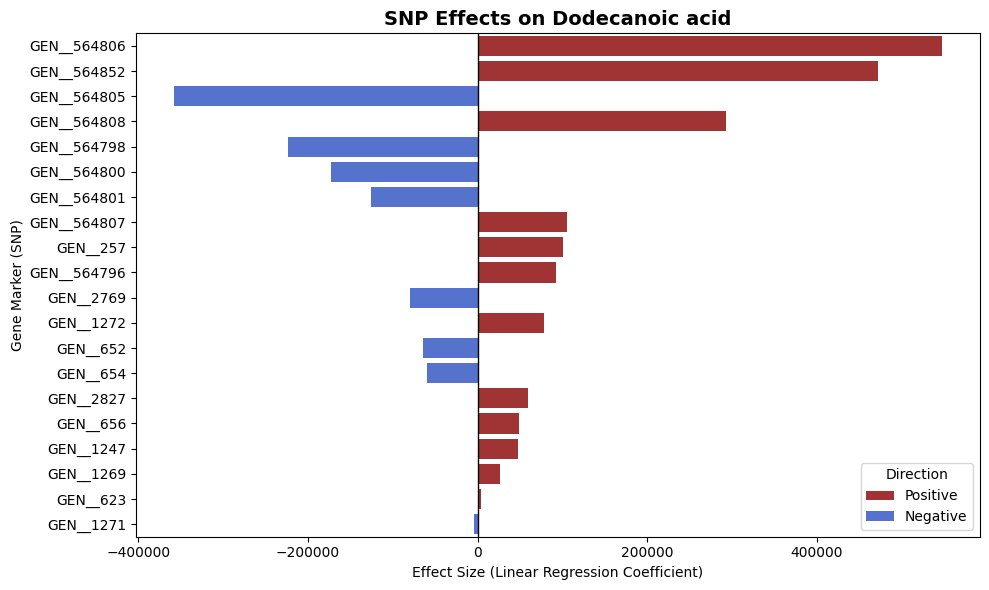


 Analyzing Ethanol, 2-phenoxy- (20 SNPs)...


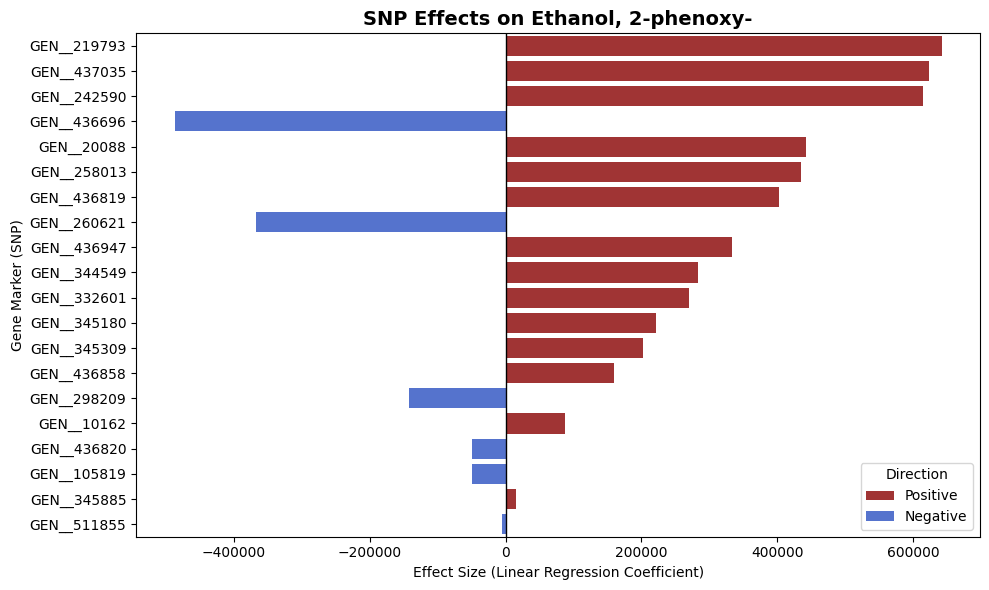


 Analyzing Ethyl acetate (20 SNPs)...


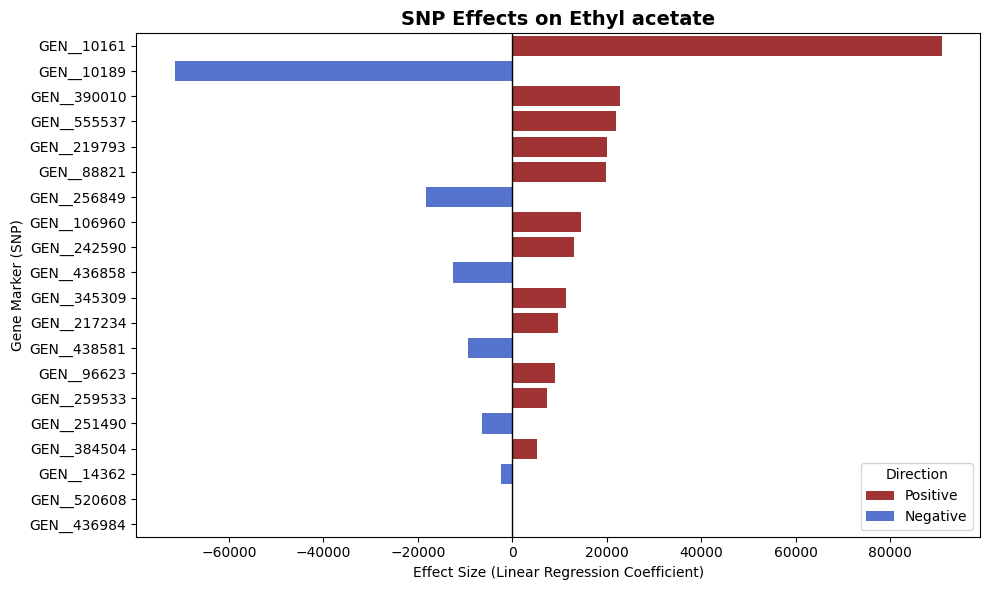


 Analyzing Ethyl butanoate (20 SNPs)...


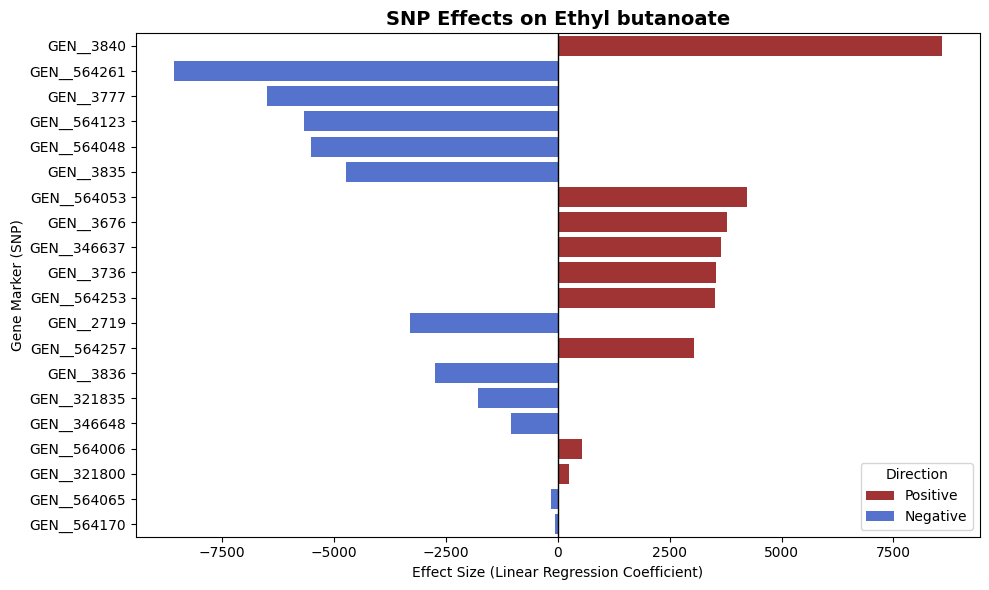


 Analyzing Furan, 2-pentyl- (20 SNPs)...


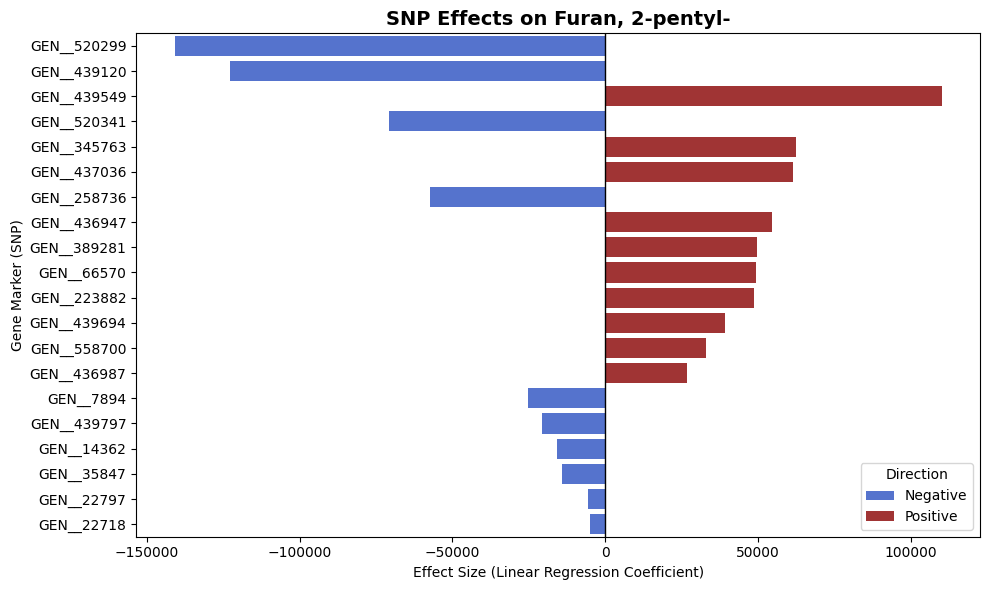


 Analyzing Furfural (20 SNPs)...


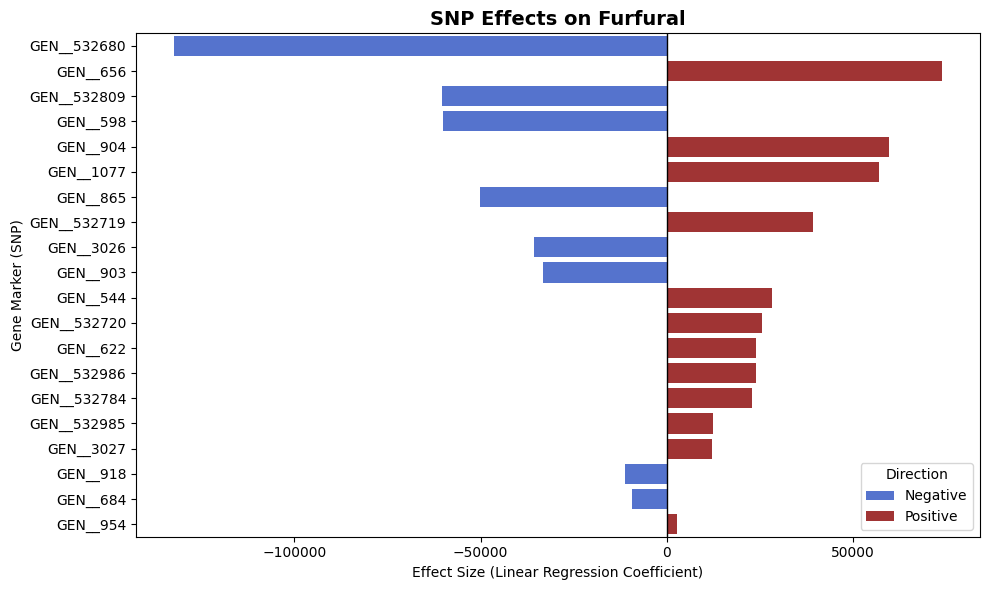


 Analyzing Hexanal (20 SNPs)...


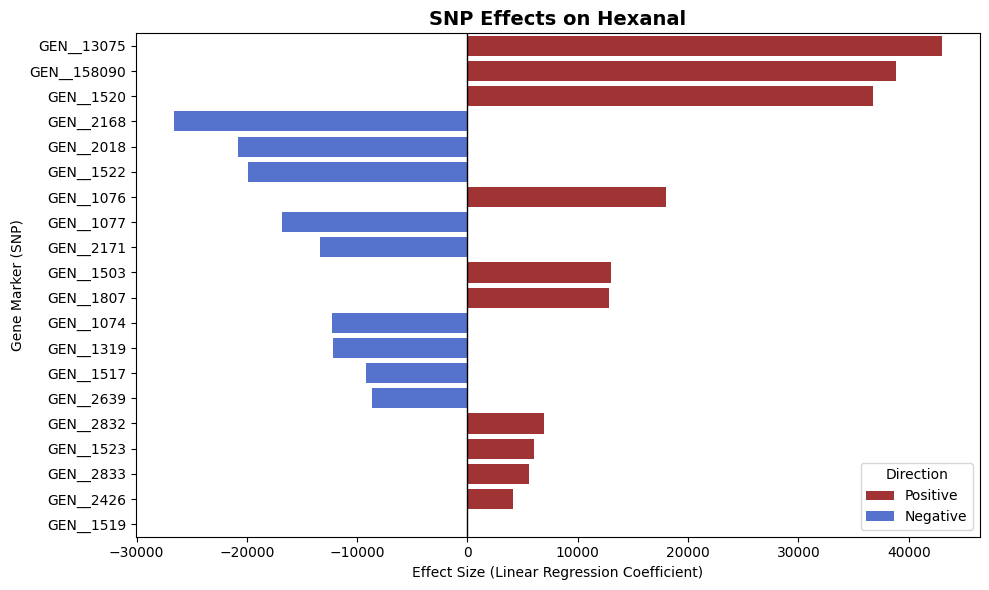


 Analyzing Hexanoic acid (20 SNPs)...


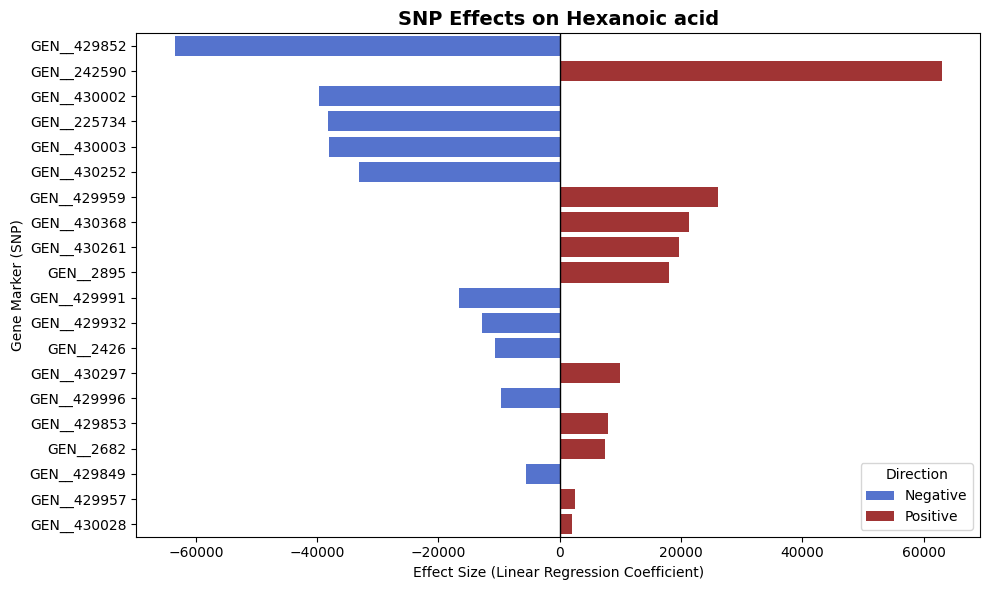


 Analyzing Hexanol (20 SNPs)...


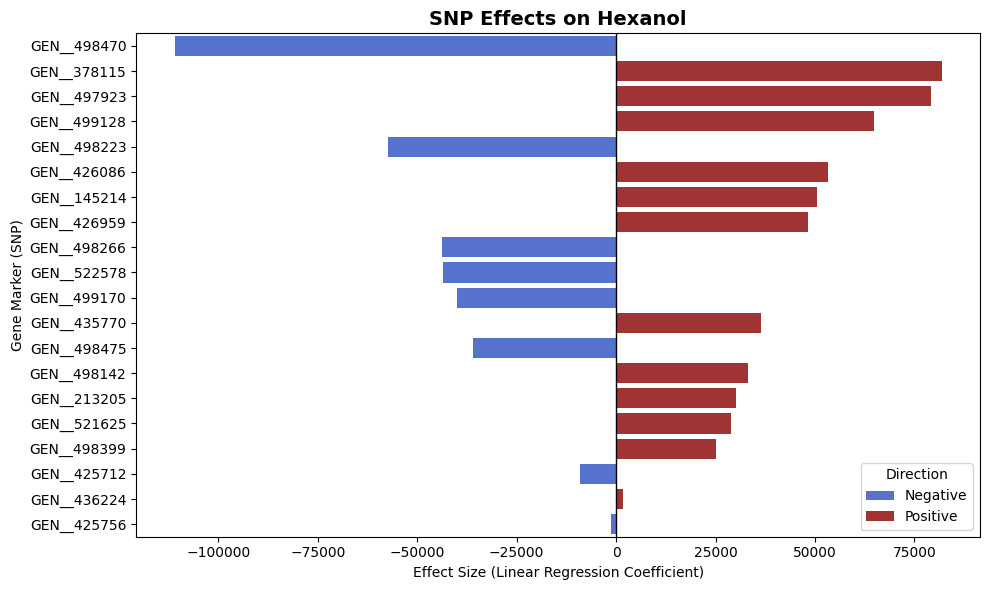


 Analyzing Methional (20 SNPs)...


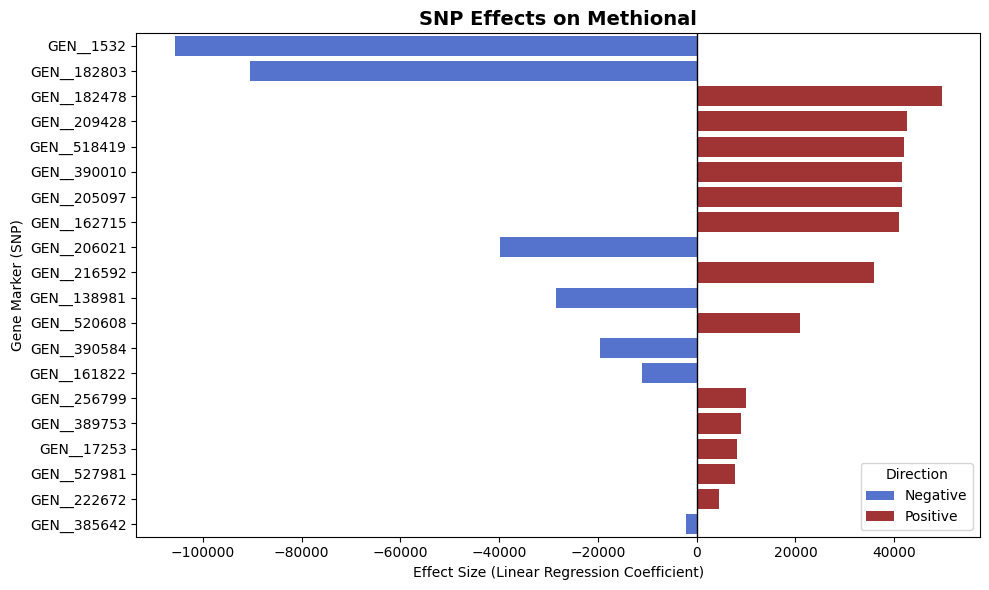


 Analyzing Methyl 8-oxooctanoate (20 SNPs)...


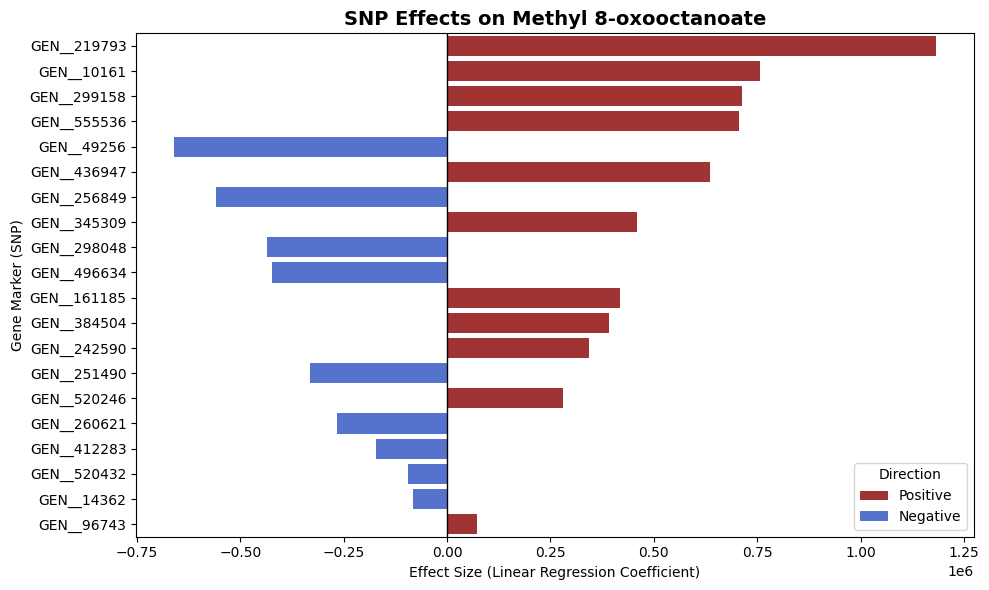


 Analyzing Nonanal (20 SNPs)...


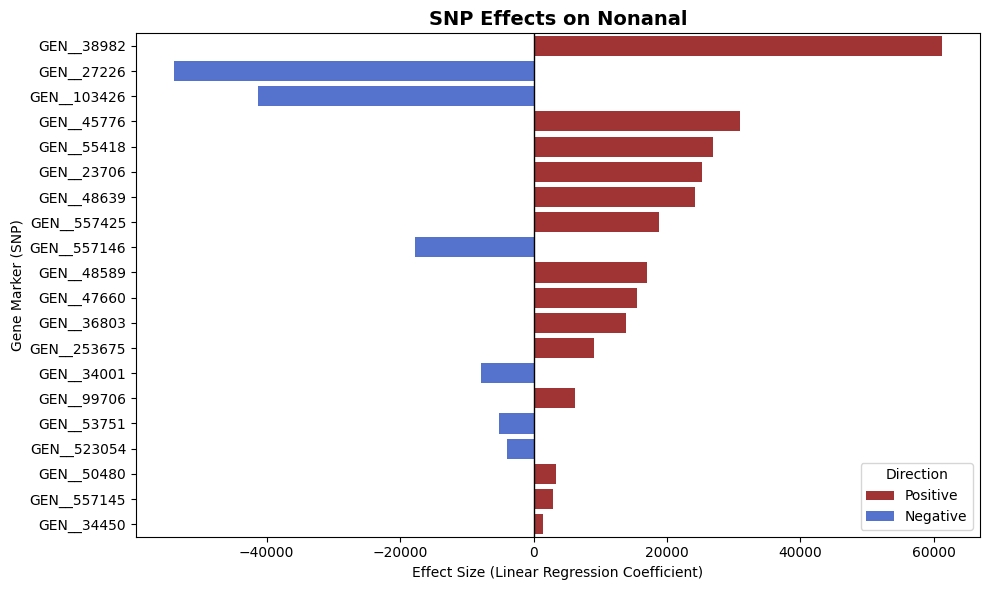


 Analyzing Octanal (20 SNPs)...


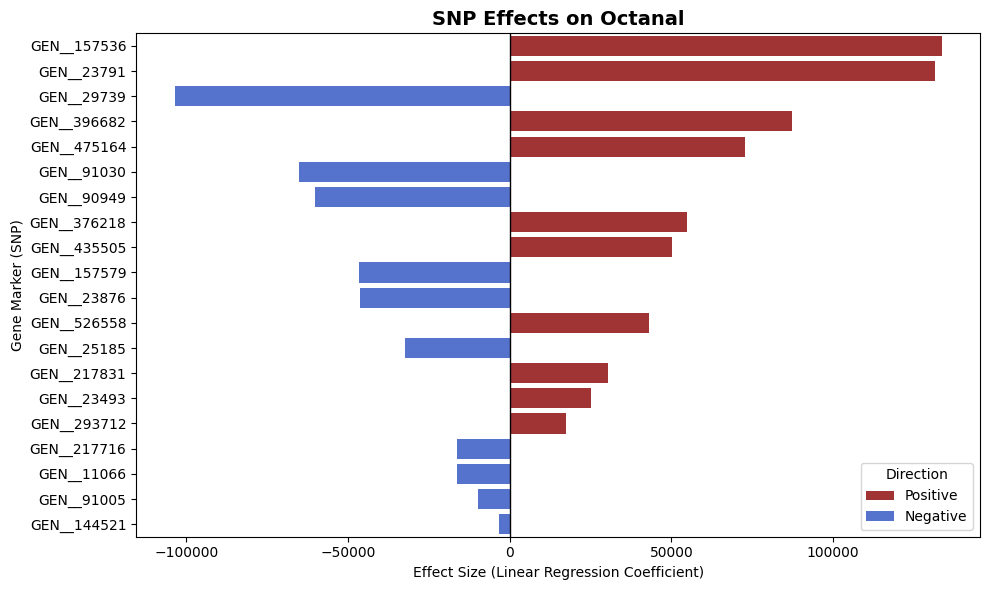


 Analyzing Octanoic acid (20 SNPs)...


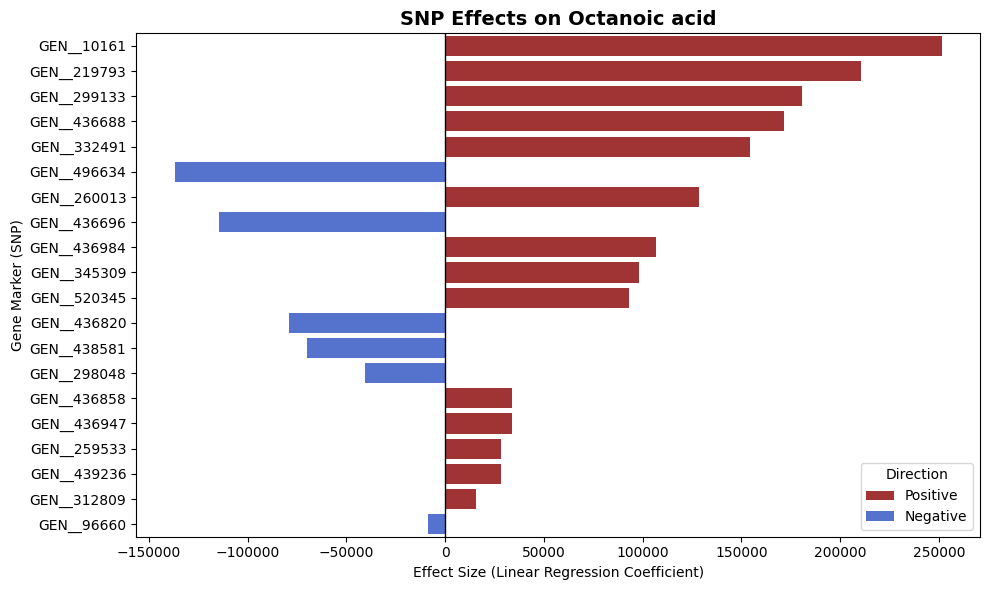


 Analyzing Octanoic acid, methyl ester (20 SNPs)...


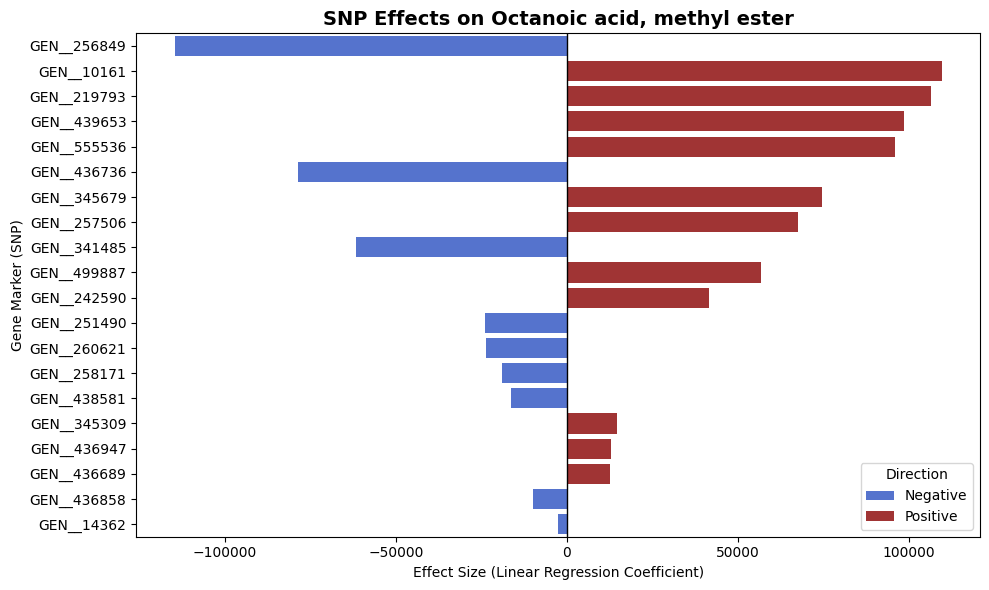


 Analyzing Pentanal (20 SNPs)...


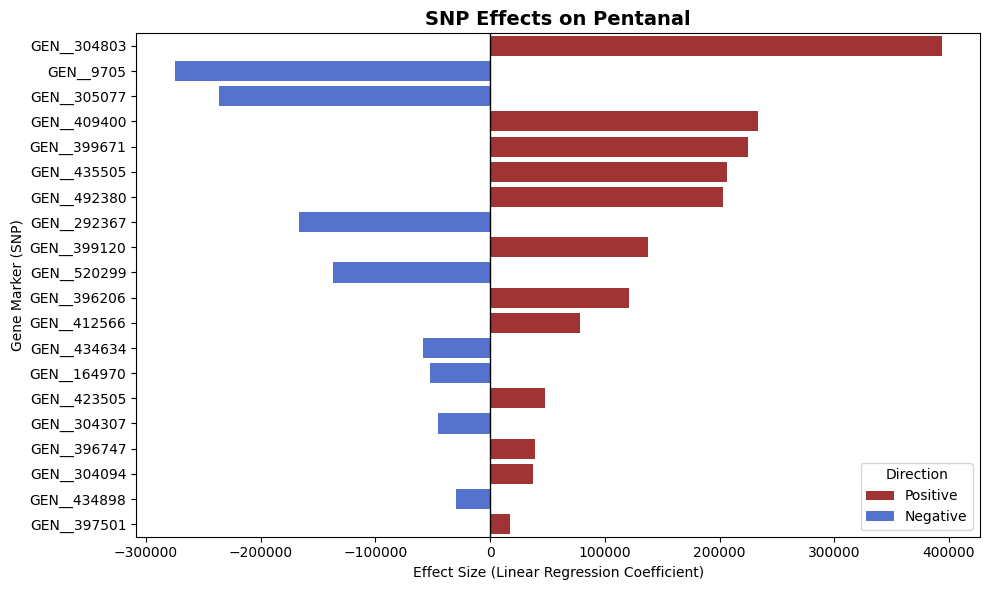


 Analyzing Phenol (20 SNPs)...


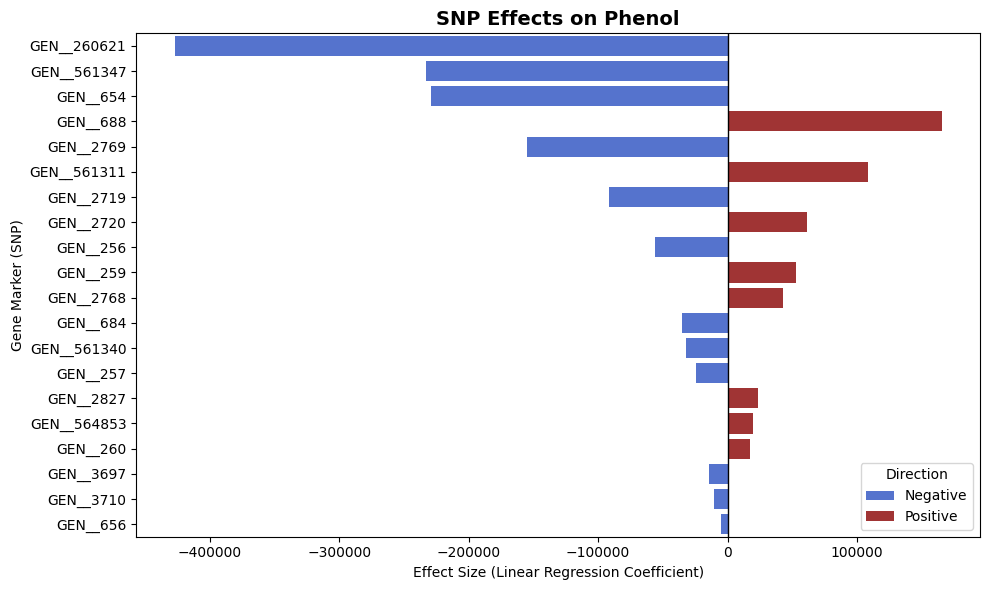


 Analyzing Phenylacetaldehyde (20 SNPs)...


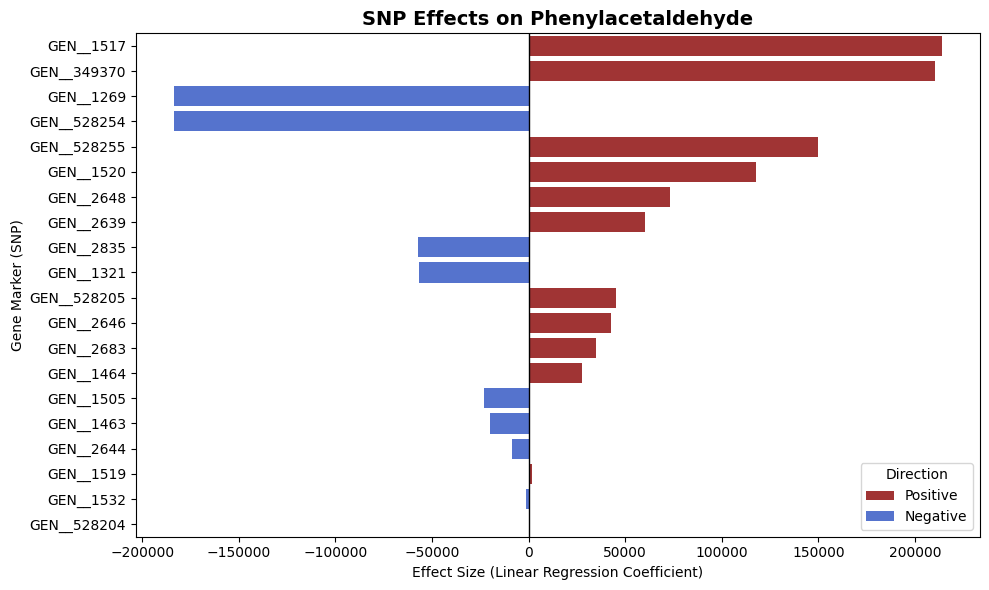


 Analyzing Propanal (20 SNPs)...


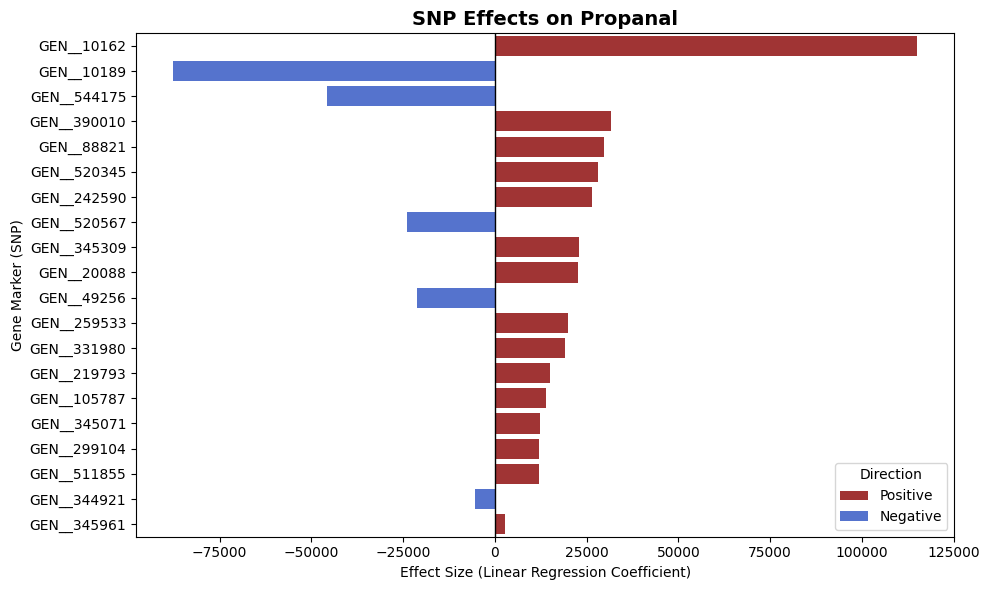


 Analyzing Propanoic acid (20 SNPs)...


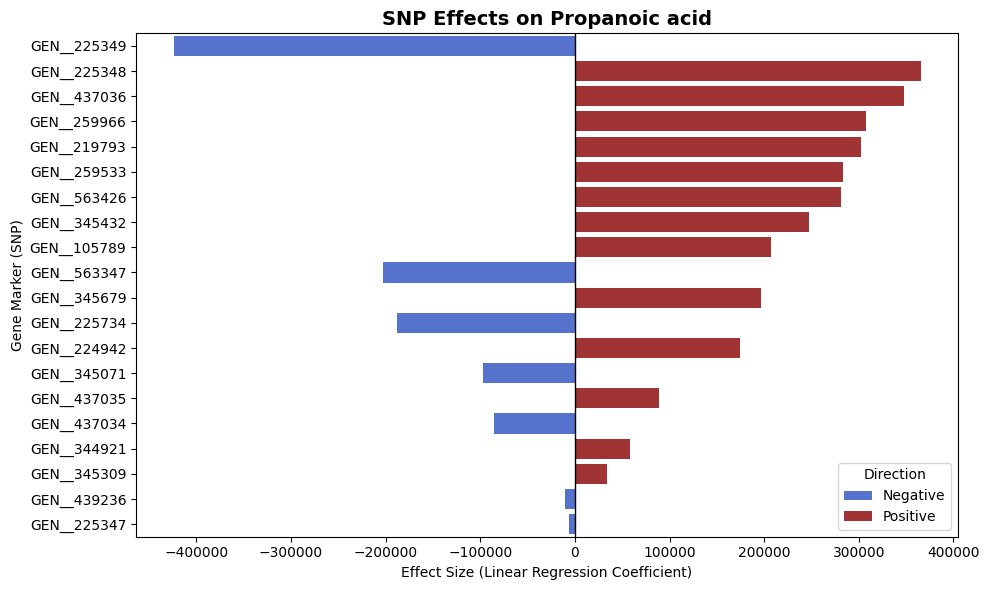


 Analyzing Styrene (20 SNPs)...


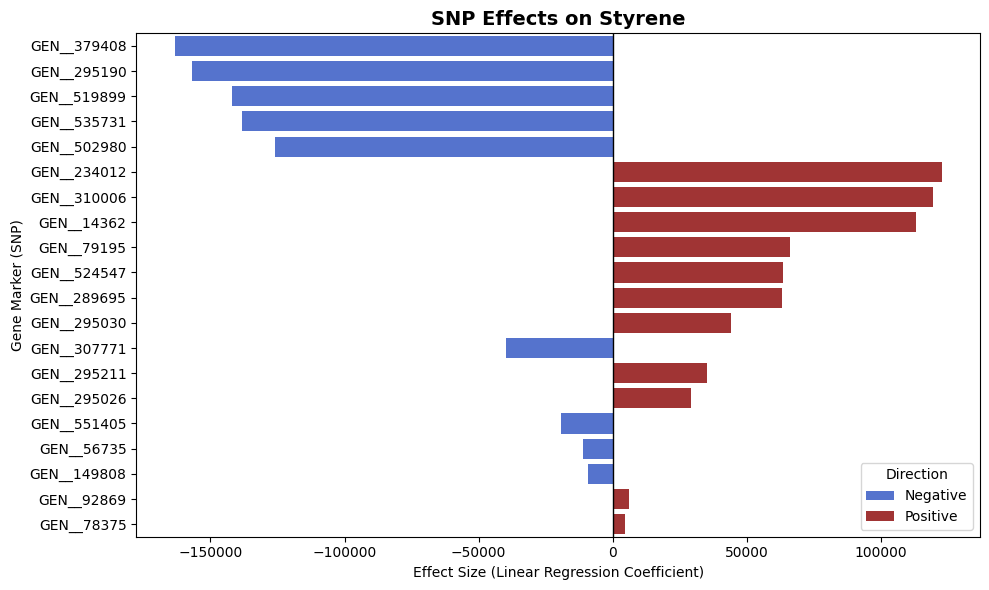


 Analyzing Tetradecanal (20 SNPs)...


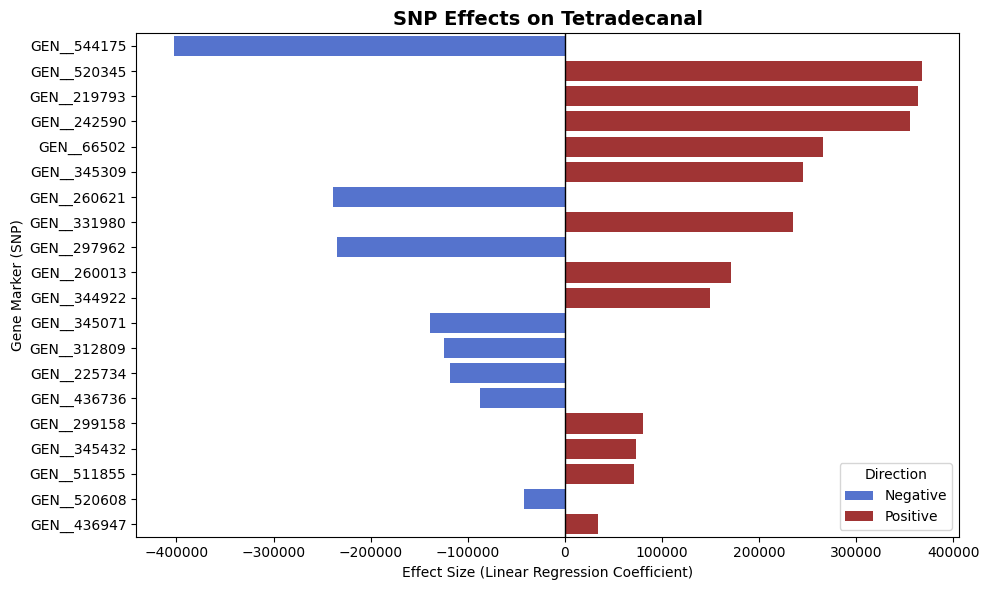


 Analyzing Tetradecane (20 SNPs)...


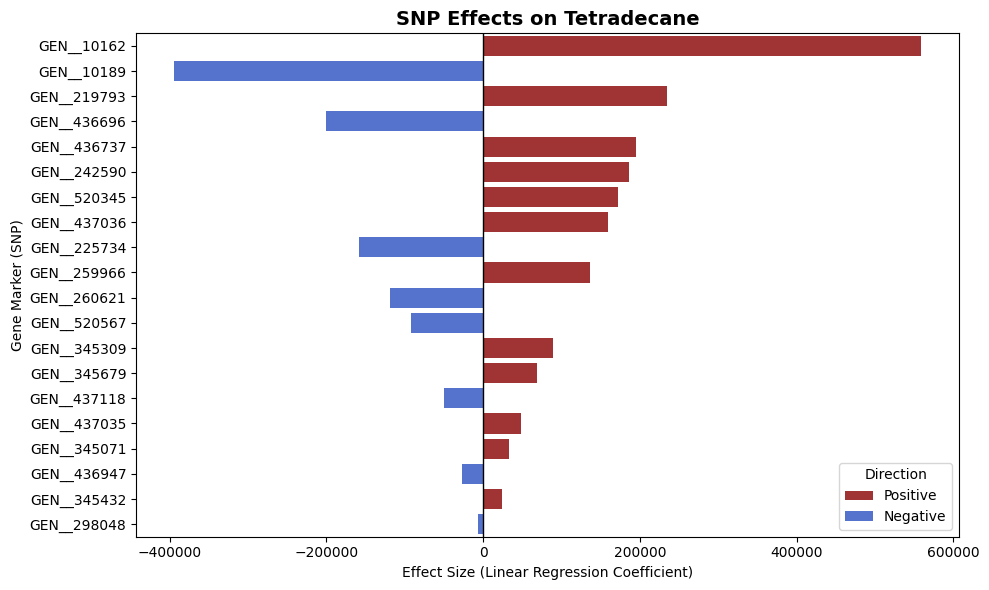


 Analyzing Tridecanal (20 SNPs)...


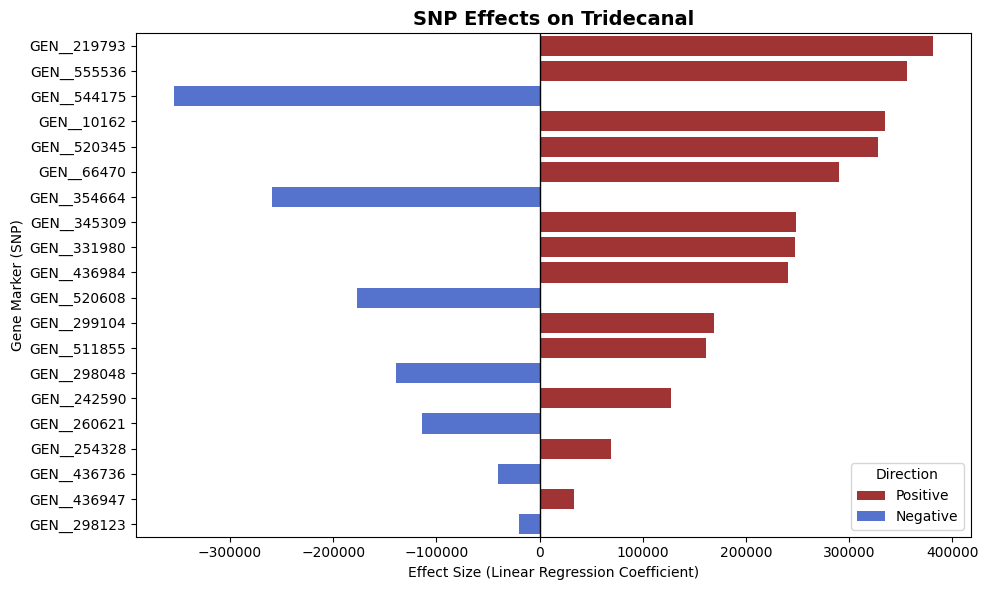


 Analyzing Tridecane (20 SNPs)...


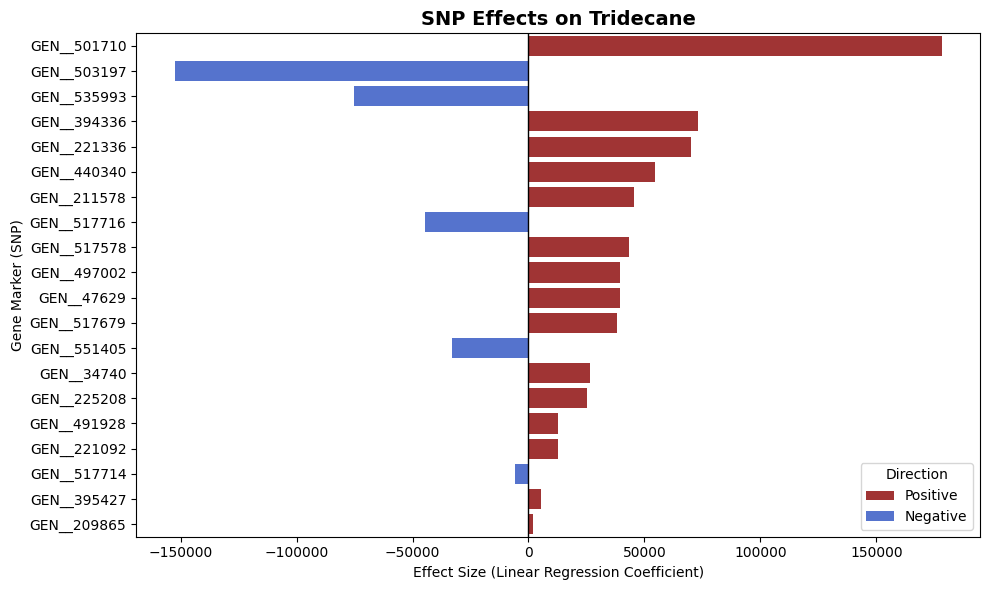


 Analyzing Undecanal (20 SNPs)...


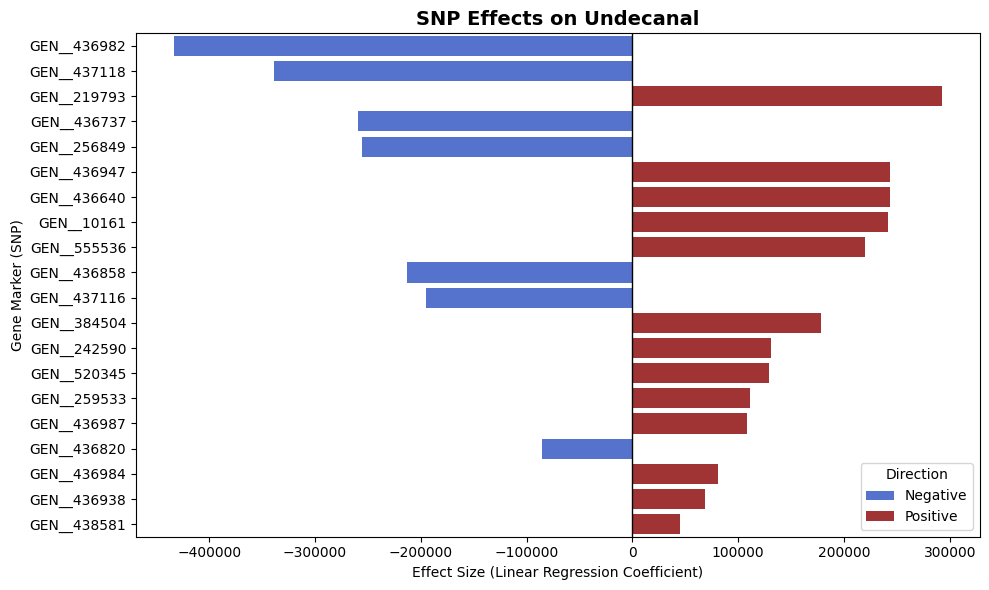


 Analyzing Unnamed: 0 (20 SNPs)...


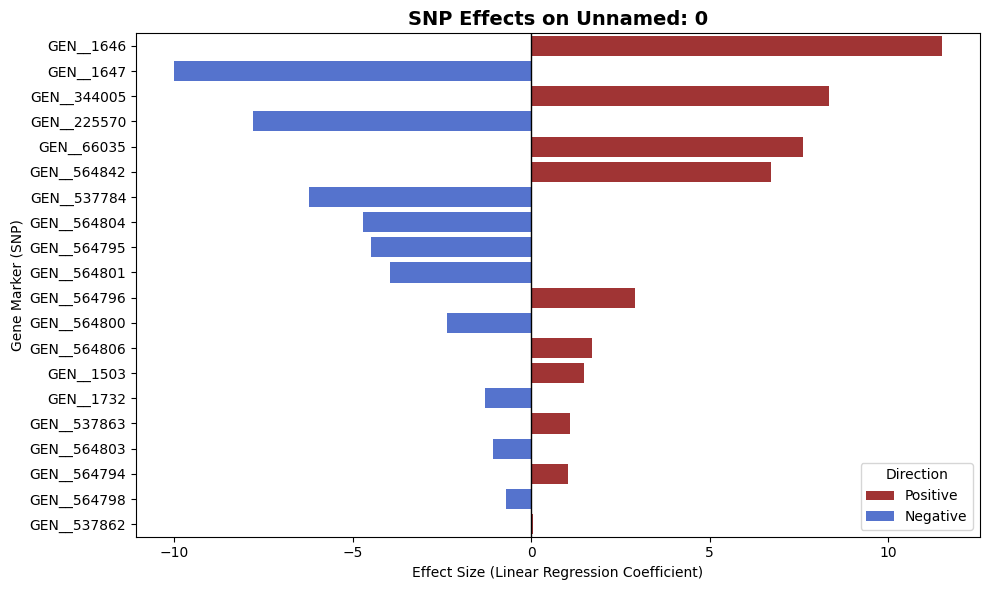


 Analyzing alpha-Terpineol (20 SNPs)...


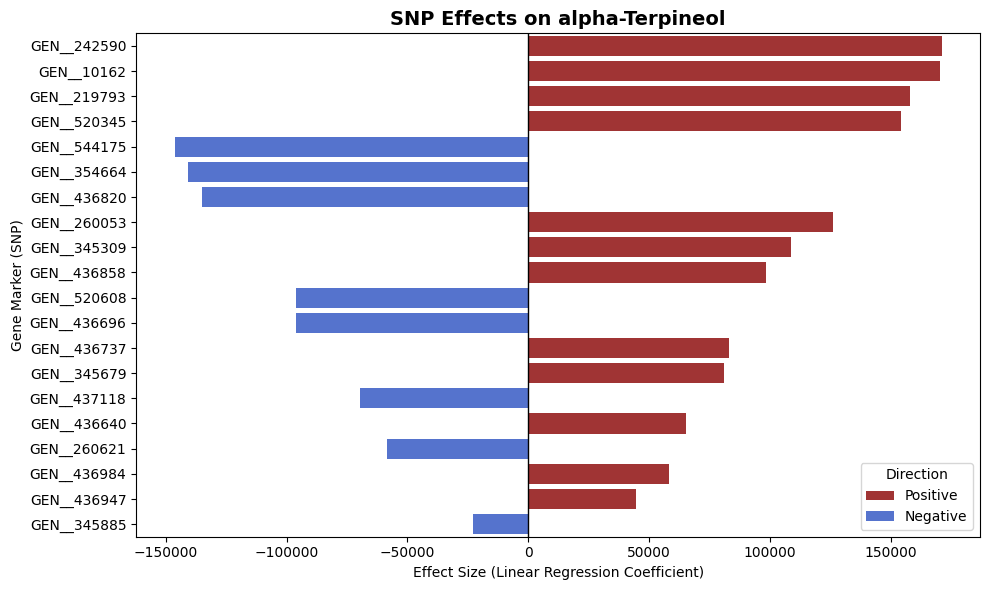


 Analyzing n-Hexadecanoic acid (20 SNPs)...


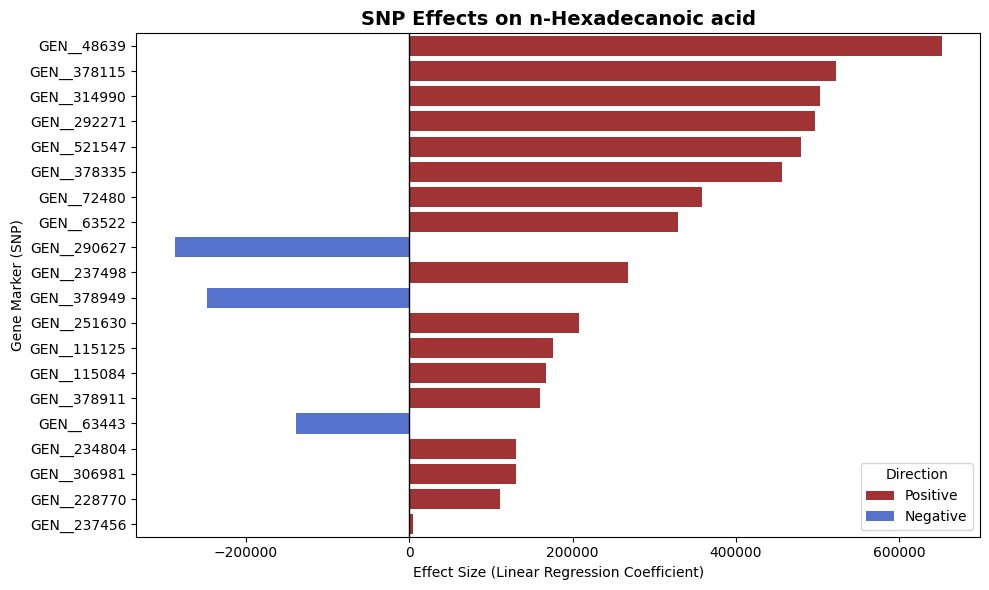


 Finished analyzing SNP effects for high-correlation traits.


,SNP,Effect,Direction,|Effect|,Trait
0,GEN__436737,126469.626260,Positive,126469.626260,(E)-2-Decenal
1,GEN__10162,70600.952006,Positive,70600.952006,(E)-2-Decenal
2,GEN__520608,-65822.238806,Negative,65822.238806,(E)-2-Decenal
3,GEN__354664,-57587.215283,Negative,57587.215283,(E)-2-Decenal
4,GEN__225734,-52815.900352,Negative,52815.900352,(E)-2-Decenal


In [ ]:
from genemarker_module import analyze_marker_effects_for_top_correlated_traits

effects_summary = analyze_marker_effects_for_top_correlated_traits(
    gwas_file=gwas_file,
    df_aroma=merged_snp_aroma,
    corr_matrix=corr_linear_sensory,
    corr_threshold=0.1,
    top_snps_per_trait=20,
    save_dir=r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep1"
)

rows = []
for trait, obj in effects_summary.items():
    if isinstance(obj, pd.DataFrame):
        tmp = obj.copy()
        tmp["Trait"] = trait
        rows.append(tmp)
    elif isinstance(obj, list):
        for r in obj:
            r = dict(r)
            r["Trait"] = trait
            rows.append(r)
    elif isinstance(obj, dict):
        r = dict(obj)
        r["Trait"] = trait
        rows.append(r)

import pandas as pd

effects_summary_df = pd.concat(
    [df.assign(Trait=trait) for trait, df in effects_summary.items()],
    ignore_index=True
)

effects_summary_df.head()



The bar plots show that different gene markers can have opposite effects on the same compound—some are associated with increased compound levels (positive effects), while others are associated with decreased levels (negative effects)

# PLSR Analysis Between High-Predictive Gene-Based Compounds and Reconstructed Sensory Attributes

# Reconstruction of sensory attributes from PCA scores


In [ ]:
from genemarker_module import reconstruct_sensory_traits_from_pca
from pathlib import Path

# Select aroma traits with sufficient genetic predictability
high_r2_traits = (
    df_linear
    .loc[df_linear["CV_R2"] >= 0.5, "Trait"]
    .unique()
    .tolist()
)

print(f"Number of high-predictive compounds: {len(high_r2_traits)}")



projection_path = config["biorep1"]["data_paths"]["sensory_pca"]["projection_path"]
loadings_path   = config["biorep1"]["data_paths"]["sensory_pca"]["loadings_path"]
save_path       = config["biorep1"]["data_paths"]["sensory_reconstructed_output"]

Path(save_path).parent.mkdir(parents=True, exist_ok=True)

# load and rename
projection = pd.read_csv(projection_path)
projection.columns = projection.columns.astype(str).str.strip()
projection = projection.rename(columns={"VARIETY": "Variety"})  # safe even if already fixed

#  drop non-PC columns if present
projection = projection.drop(columns=["is_panel"], errors="ignore")

projection_path = "results/biorep1/sensory_pca_projection_knn_fixed.csv"
Path(projection_path).parent.mkdir(parents=True, exist_ok=True)
projection.to_csv(projection_path, index=False)

#  run reconstruction 
sensory_reconstructed_df = reconstruct_sensory_traits_from_pca(
    projection_path=projection_path,
    loadings_path=loadings_path,
    save_path=save_path,
    n_components=3
)


Number of high-predictive compounds: 38
 Reconstructed sensory traits using 3 PCs:


,METALLIC FLAVOUR,BITTER FLAVOUR,EARTHY FLAVOUR,SOUR FLAVOUR,FRESH FLAVOUR,SWEET FLAVOUR,ROOT/ VEGETABLE FLAVOUR,FARMYARD (GRASS/HAY) FLAVOUR,BITTER AFTERTASTE,SOUR AFTERTASTE,SWEET AFTERTASTE,EARTHY AROMA,FARMYARD,SWEET,STARCHY,DAMP,BUTTERY,FRESH,POTATO STARCH,METALIC
Variety,,,,,,,,,,,,,,,,,,,,
ADORA,2.777227,3.021468,2.221376,2.850300,-1.066084,-0.847148,2.373826,2.495142,2.784747,3.016634,-1.006645,0.899148,1.878034,-0.157331,0.828773,1.786741,-0.069789,-0.149353,-0.225817,2.325663
AGRIA,-0.229637,-0.448615,0.509891,-0.827166,-0.731611,-1.171877,0.083648,0.310391,-0.388611,-1.042706,-1.130200,1.387898,-0.340720,-0.651435,1.694207,-0.093582,-0.849283,-1.680008,2.088016,0.320938
BERBER,-0.354242,-0.459819,0.098332,-0.640353,0.861787,0.459095,0.873152,0.428063,-0.596838,-0.754492,0.370748,-0.125063,-0.278329,1.418112,1.733750,-1.048533,1.192578,-0.023029,1.404938,-0.173067
BILDTSTAR,-0.143122,-0.293976,0.317844,-0.535582,-0.939388,-1.155316,-0.367521,0.003764,-0.178766,-0.677375,-1.078262,1.199855,-0.238350,-1.130382,0.698996,0.290940,-1.208747,-1.412395,1.204038,0.265307
BINTJE,-0.896907,-1.004481,-0.571348,-1.026723,0.614686,0.401464,-0.323025,-0.523106,-0.990835,-1.116110,0.412158,-0.289270,-0.621746,0.574778,0.430797,-0.885742,0.465161,0.026589,0.598025,-0.702797


 Saved reconstructed sensory traits → results/sensory_reconstructed/sensory_reconstructed_biorep1.csv


 Common varieties found: 86
 Using 38 genetically predictable compounds for PLSR
 Fitted PLS model with 5 components


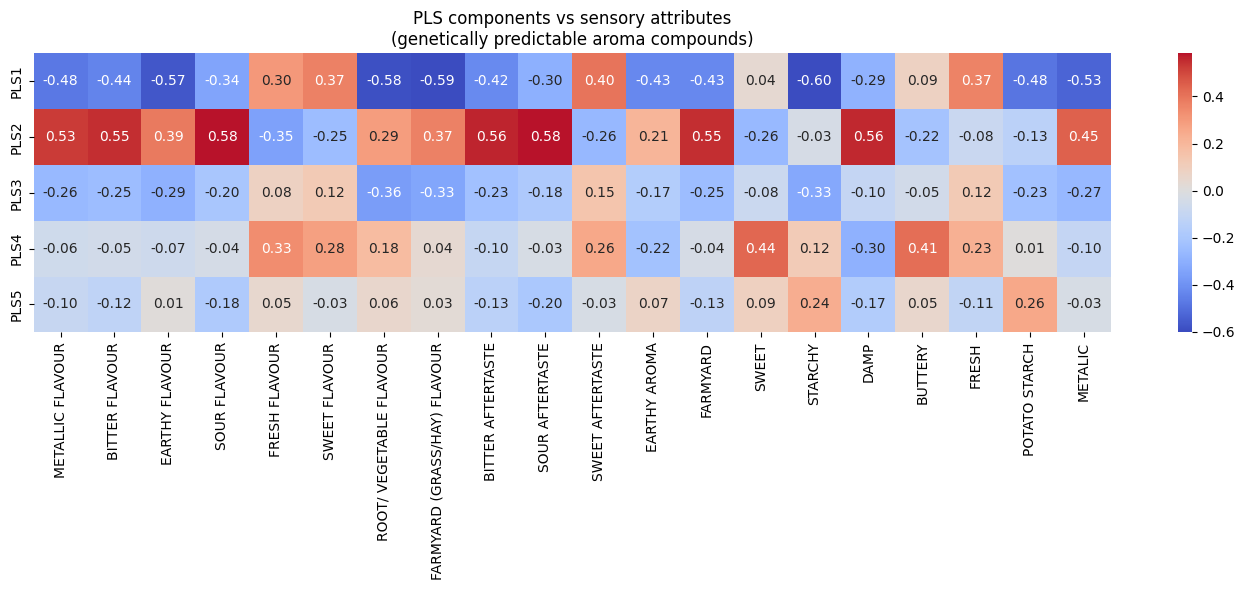

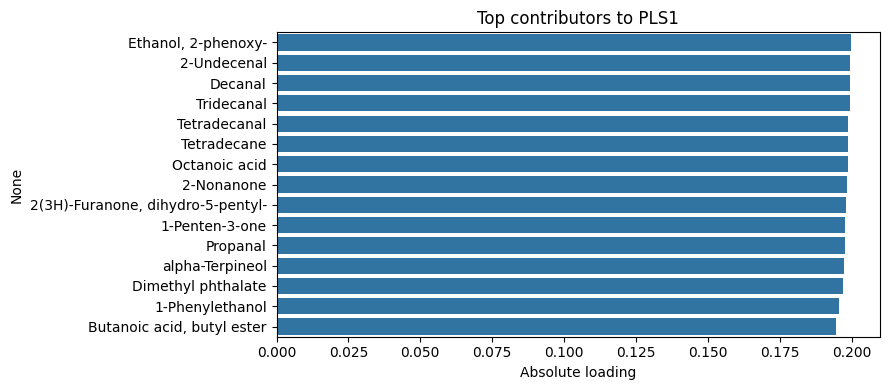

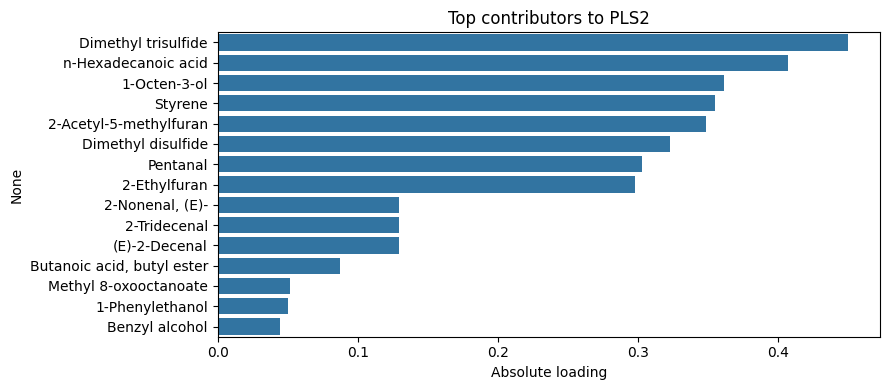

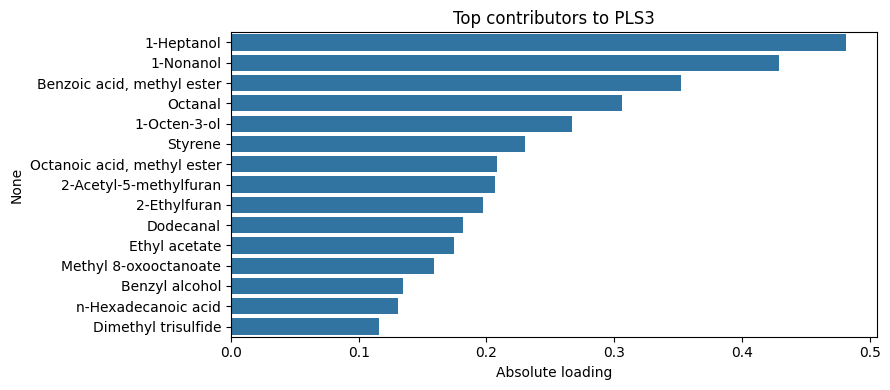

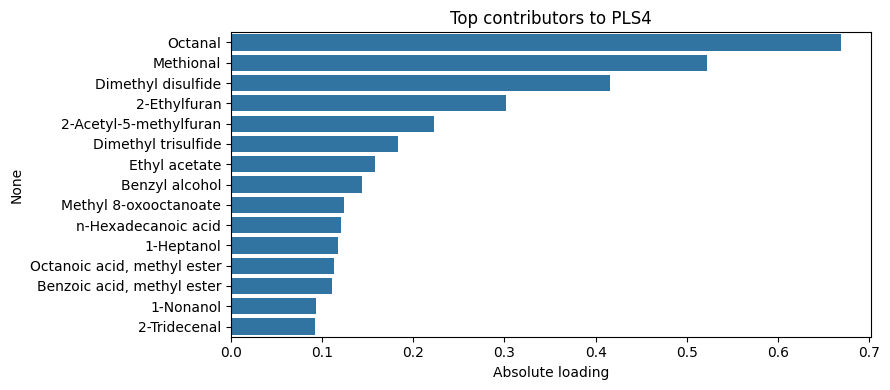

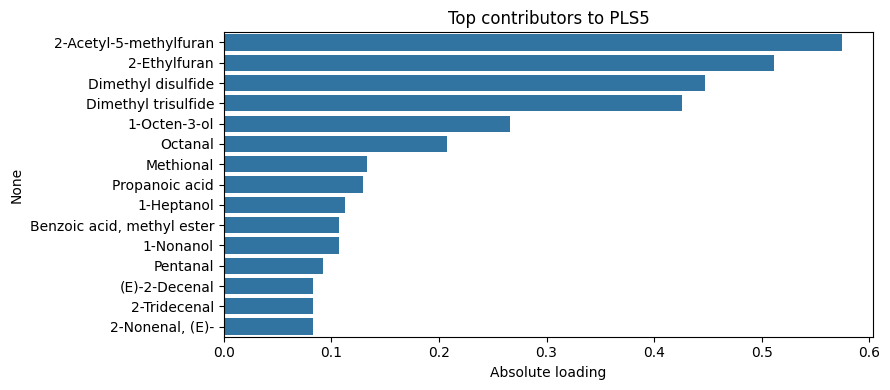

In [ ]:
from genemarker_module import run_plsr_gene_predictable_vs_sensory


save_dir = config["biorep1"]["data_paths"]["plsr_gene_vs_sensory_dir"]
Path(save_dir).mkdir(parents=True, exist_ok=True)

plsr_results = run_plsr_gene_predictable_vs_sensory(
    aroma_df=merged_snp_aroma,
    sensory_reconstructed_path=save_path,
    high_r2_traits=high_r2_traits,
    save_dir=save_dir,
    n_components=5
)


From the heatmap, PLS1 shows positive associations with fresh/sweet attributes and more negative associations with starchy/potato starch, suggesting a gradient from fresh/sweet to starchy sensory space. PLS2 aligns more with sour/bitter/metallic/earthy/damp attributes and tends to be negative for fresh/sweet, indicating a harsher / more metallic–sour–bitter axis. The contributor barplots highlight which VOCs drive these components; for example, PLS2 is strongly influenced by sulfur-related compounds (e.g., dimethyl di-/tri-sulfide) alongside a few other VOCs, suggesting these compounds are key links between genetic signals, aroma chemistry, and sensory perception.

# PLSR Analysis Between Gene-Predicted Aroma Compounds and Sensory Attribute biplot

 Common varieties found: 86
X_scaled shape: (86, 38), Y_scaled shape: (86, 20)
PLSR fitted with 5 components


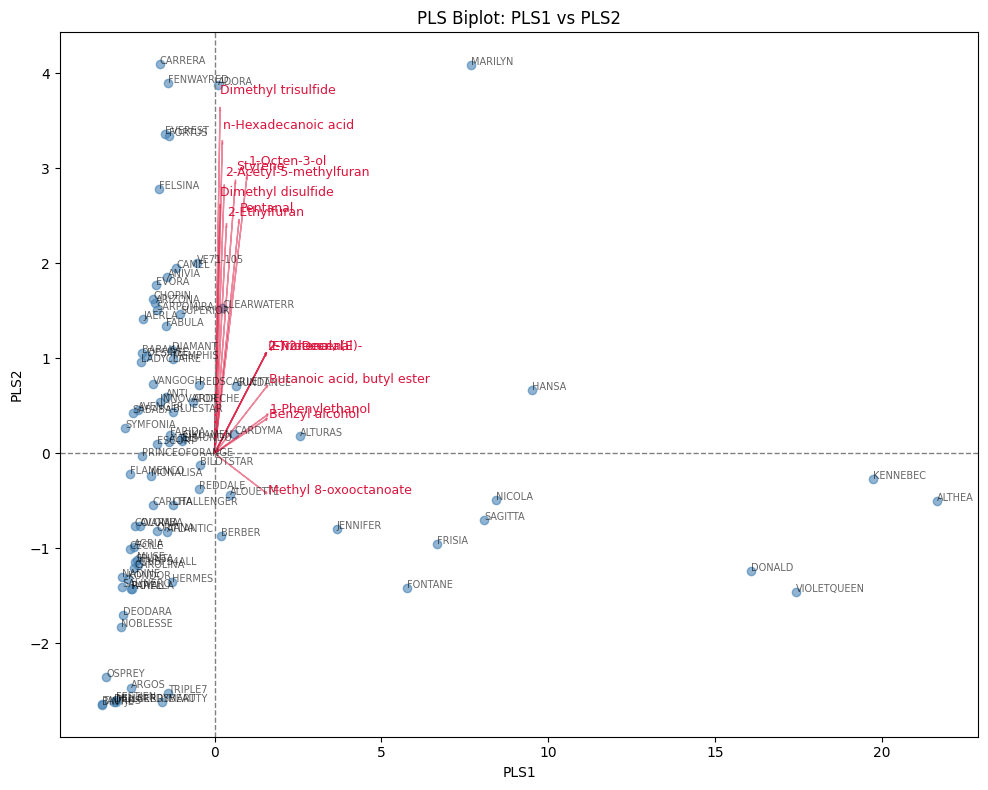

In [ ]:
from genemarker_module import prepare_plsr_data, plot_plsr_biplot

# Prepare PLSR input matrices
X, Y, X_scaled, Y_scaled = prepare_plsr_data(
    predictions=merged_snp_aroma,
    high_r2_traits=high_r2_traits,
    sensory_reconstructed_path=save_path
)

# Safe component selection
n_components = min(
    5,
    X_scaled.shape[1],
    Y_scaled.shape[1],
    X_scaled.shape[0] - 1   # important: avoid rank issues
)

pls = PLSRegression(n_components=n_components)
pls.fit(X_scaled, Y_scaled)

print(f"PLSR fitted with {n_components} components")


# Biplot
plot_plsr_biplot(
    pls_model=pls,
    X_scaled=X_scaled,
    pc1=1,
    pc2=2,
    top_n_loadings=15,
    rotate="none",
    show_labels=True
)


Most varieties sit near the origin, so their genetically predictable VOC profiles are broadly similar in the first two PLS components. PLS1 mainly separates a few clear outliers to the far right (e.g., ALTHEA/KENNEBEC, also DONALD/VIOLETQUEEN), meaning those genotypes have a distinct overall predicted aroma signature. PLS2 is strongly driven by the upward VOC loadings—especially dimethyl trisulfide/disulfide (and n-hexadecanoic acid, 1-octen-3-ol)—so varieties with high PLS2 scores are associated with higher levels of these compounds. Longer arrows indicate the VOCs contributing most to the separation.